In [1]:
! uv pip install ../.[training] --no-deps

Using Python 3.12.10 environment at: /home/dmp131/anaconda3/envs/cshark
Resolved 1 package in 5ms                                            
   Building cshark @ file:///home/dmp131/C.Shark                       
   Building cshark @ file:///home/dmp131/C.Shark               
   Building cshark @ file:///home/dmp131/C.Shark               
   Building cshark @ file:///home/dmp131/C.Shark               
   Building cshark @ file:///home/dmp131/C.Shark               
   Building cshark @ file:///home/dmp131/C.Shark               
   Building cshark @ file:///home/dmp131/C.Shark               
   Building cshark @ file:///home/dmp131/C.Shark               
   Building cshark @ file:///home/dmp131/C.Shark               
   Building cshark @ file:///home/dmp131/C.Shark               
   Building cshark @ file:///home/dmp131/C.Shark               
   Building cshark @ file:///home/dmp131/C.Shark               
      Built cshark @ file:///home/dmp131/C.Shark               
Prepared 1 package

In [2]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'  # Disable GPU
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from IPython.display import Image

def display_images(image_path1, image_path2):
        # read images
        img_A = mpimg.imread(image_path1)
        img_B = mpimg.imread(image_path2)

        # pad top with white space
        larger = max(img_A.shape[0], img_B.shape[0])
        img_A = np.pad(img_A, ((larger - img_A.shape[0], 0), (0, 0), (0, 0)), mode='constant', constant_values=1)
        img_B = np.pad(img_B, ((larger - img_B.shape[0], 0), (0, 0), (0, 0)), mode='constant', constant_values=1)

        # stack
        img = np.concatenate((img_A, img_B), axis=1)
        # save tmp image
        tmp_path = 'tmp.png'
        plt.imsave(tmp_path, img)
        return Image(tmp_path, width=600)

In [3]:
checkpoint = '/mnt/jinstore/JinLab02/dmp131/C.Shark/checkpoints/deeploop_hESC_universal_5kb.ckpt'

chrom = 'chr11'
start = 31000000
region = 'chr11:31373941-33024355'
ko_start = start 
ko_width = 2000000

# chrom = 'chr12'
# start = 113000000
# region = 'chr12:113674023-115079631'
# # ko_start = 113850000
# # ko_width = 65000
# ko_start = 113000000
# ko_width = 2000000

# chrom = 'chr11'
# start = 10000000
# region = 'chr11:10107449-10982145'
# ko_start = 10370000
# ko_width = 100000

# chrom = 'chr10'
# start = 14000000
# # region = 'chr10:14980000-15200000'
# region = 'chr10:14820000-15250000'
# ko_start = 15000000 - 10000
# ko_width = 60000

# chrom = 'chr7'
# start = 23000000
# region = 'chr7:23200000-23700000'
# ko_start = 23570000
# ko_width = 20000

# chrom = 'chr7'
# start = 97000000
# region = 'chr7:97600000-97900000'
# ko_start = 97790000
# ko_width = 20000

# chrom = 'chr1'
# start = 89000000
# region = 'chr1:89530000-89800000'
# ko_start = 89550000
# ko_width = 20000

region_start = region.split(':')[1].split('-')[0]
region_end = region.split(':')[1].split('-')[1]
region_len = int(region_end) - int(region_start)

In [4]:
! python ../src/cshark/inference/perturb.py \
    --celltype hESC_WT_5kb_norm_10 \
    --outname baseline \
    --chr $chrom \
    --start $start \
    --model $checkpoint \
    --seq ../cshark_data/data/hg19/dna_sequence \
    --matrix-size 512 \
    --resolution 4096 \
    --region $region \
    --min-val-pred 0.1 \
    --plot-bigwigs ctcf atac rad21 \
    --plot-pred-bigwigs ctcf atac rad21 \
    --bigwigs ctcf=../cshark_data/data/hg19/hESC_WT_5kb_norm_10/genomic_features/ctcf.bw \
              atac=../cshark_data/data/hg19/hESC_WT_5kb_norm_10/genomic_features/atac.bw \
    --silent

(4096, 5)
(4096, 5)


Here we compare the experimental data to the prediction:

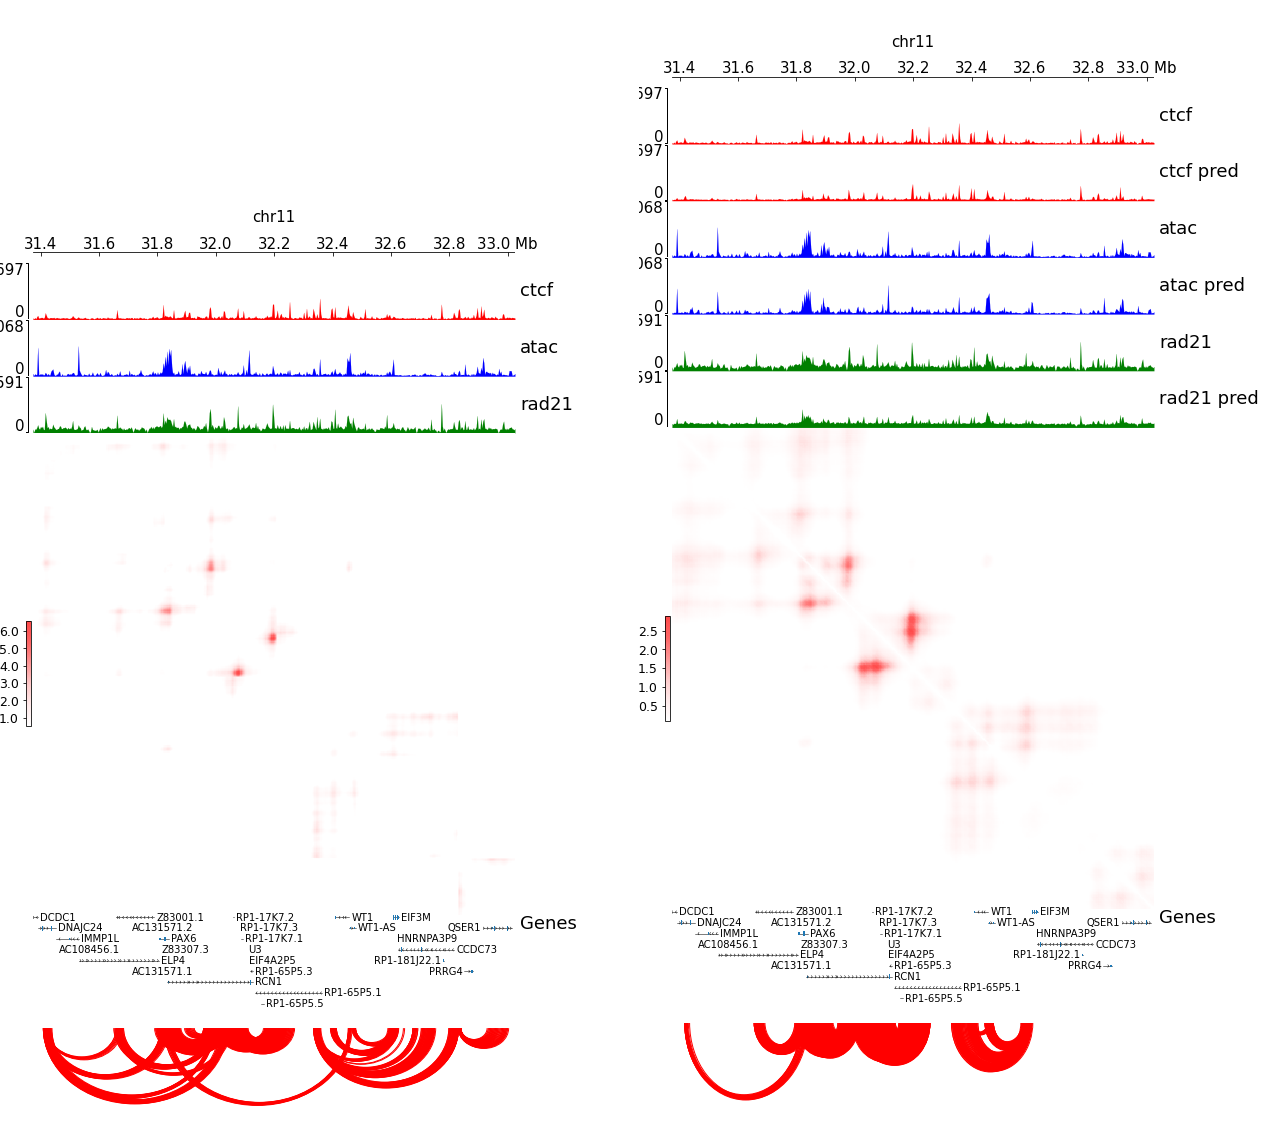

In [5]:
display_images(f'outputs/baseline_hESC_WT_5kb_norm_10_{chrom}_{start}_ctcf_true_tracks.png', 
               f'outputs/baseline_hESC_WT_5kb_norm_10_{chrom}_{start}_ctcf_pred_tracks.png')

In [6]:
! python ../src/cshark/inference/perturb.py \
    --celltype hESC_WT_5kb_norm_10 \
    --outname ctcf_ko_only \
    --chr $chrom \
    --start $start \
    --model $checkpoint \
    --seq ../cshark_data/data/hg19/dna_sequence \
    --matrix-size 512 \
    --resolution 4096 \
    --region $region \
    --ko-start $ko_start \
    --ko-width $ko_width \
    --ko seq \
    --ko-mode shuffle \
    --peak-height 0.05 \
    --min-val-pred 0.0 \
    --max-val-pred 3.0 \
    --plot-bigwigs rad21 \
    --plot-pred-bigwigs ctcf atac rad21 \
    --bigwigs ctcf=../cshark_data/data/hg19/hESC_WT_5kb_norm_10/genomic_features/ctcf.bw \
              atac=../cshark_data/data/hg19/hESC_WT_5kb_norm_10/genomic_features/atac.bw \
    --silent

(4096, 5)
(4096, 5)


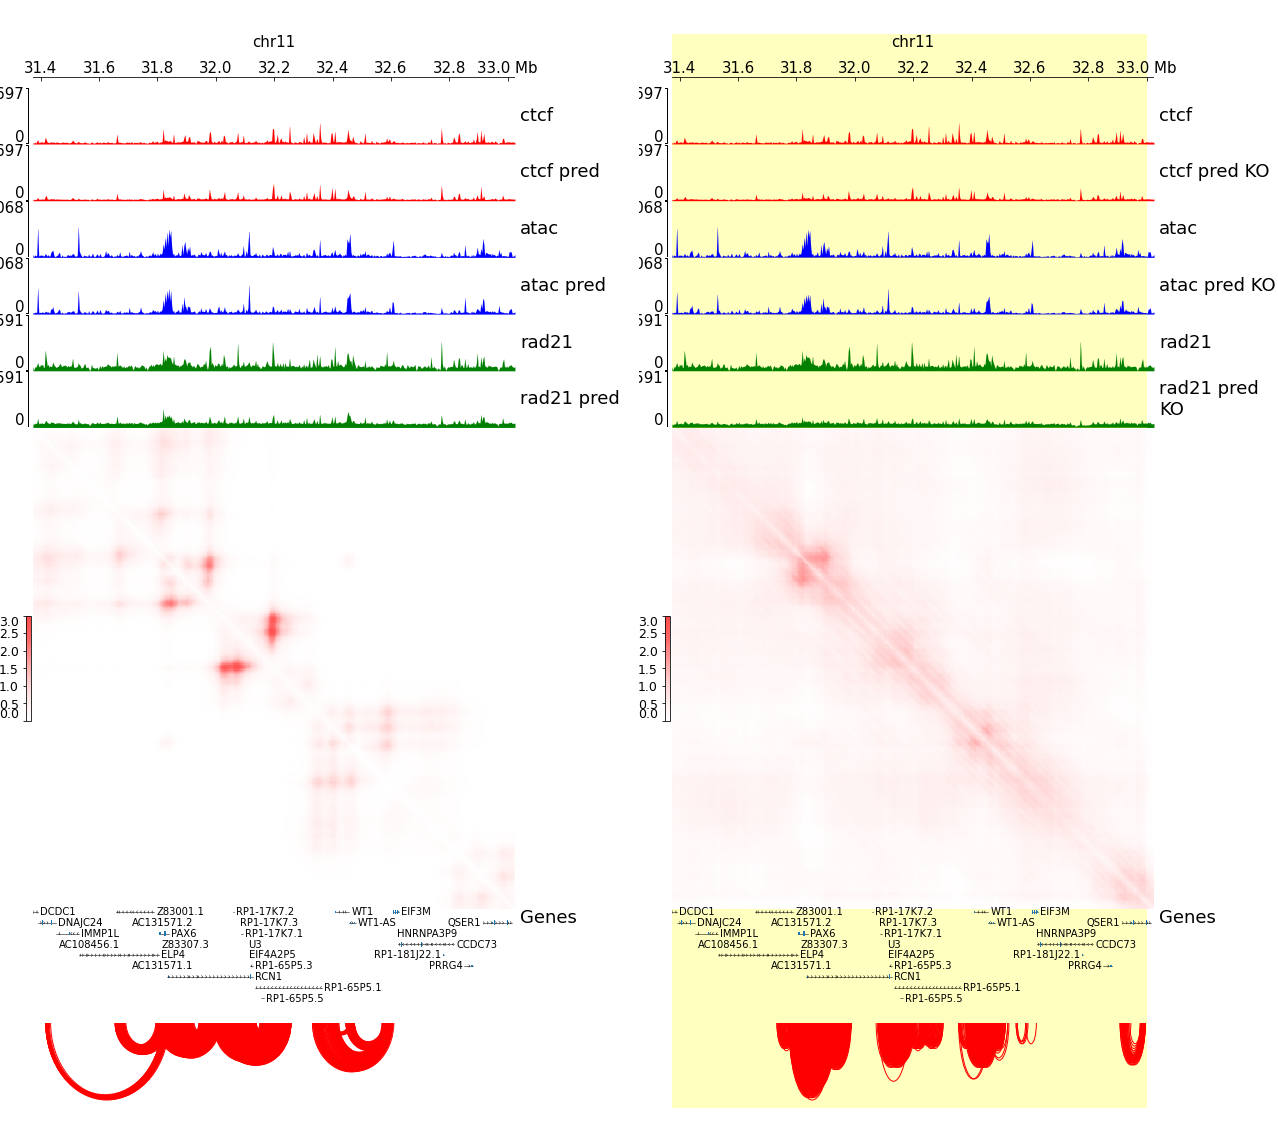

In [7]:
display_images(f'outputs/ctcf_ko_only_hESC_WT_5kb_norm_10_{chrom}_{start}_ctcf_pred_tracks.png', 
               f'outputs/ctcf_ko_only_hESC_WT_5kb_norm_10_{chrom}_{start}_ctcf_ko_tracks.png')

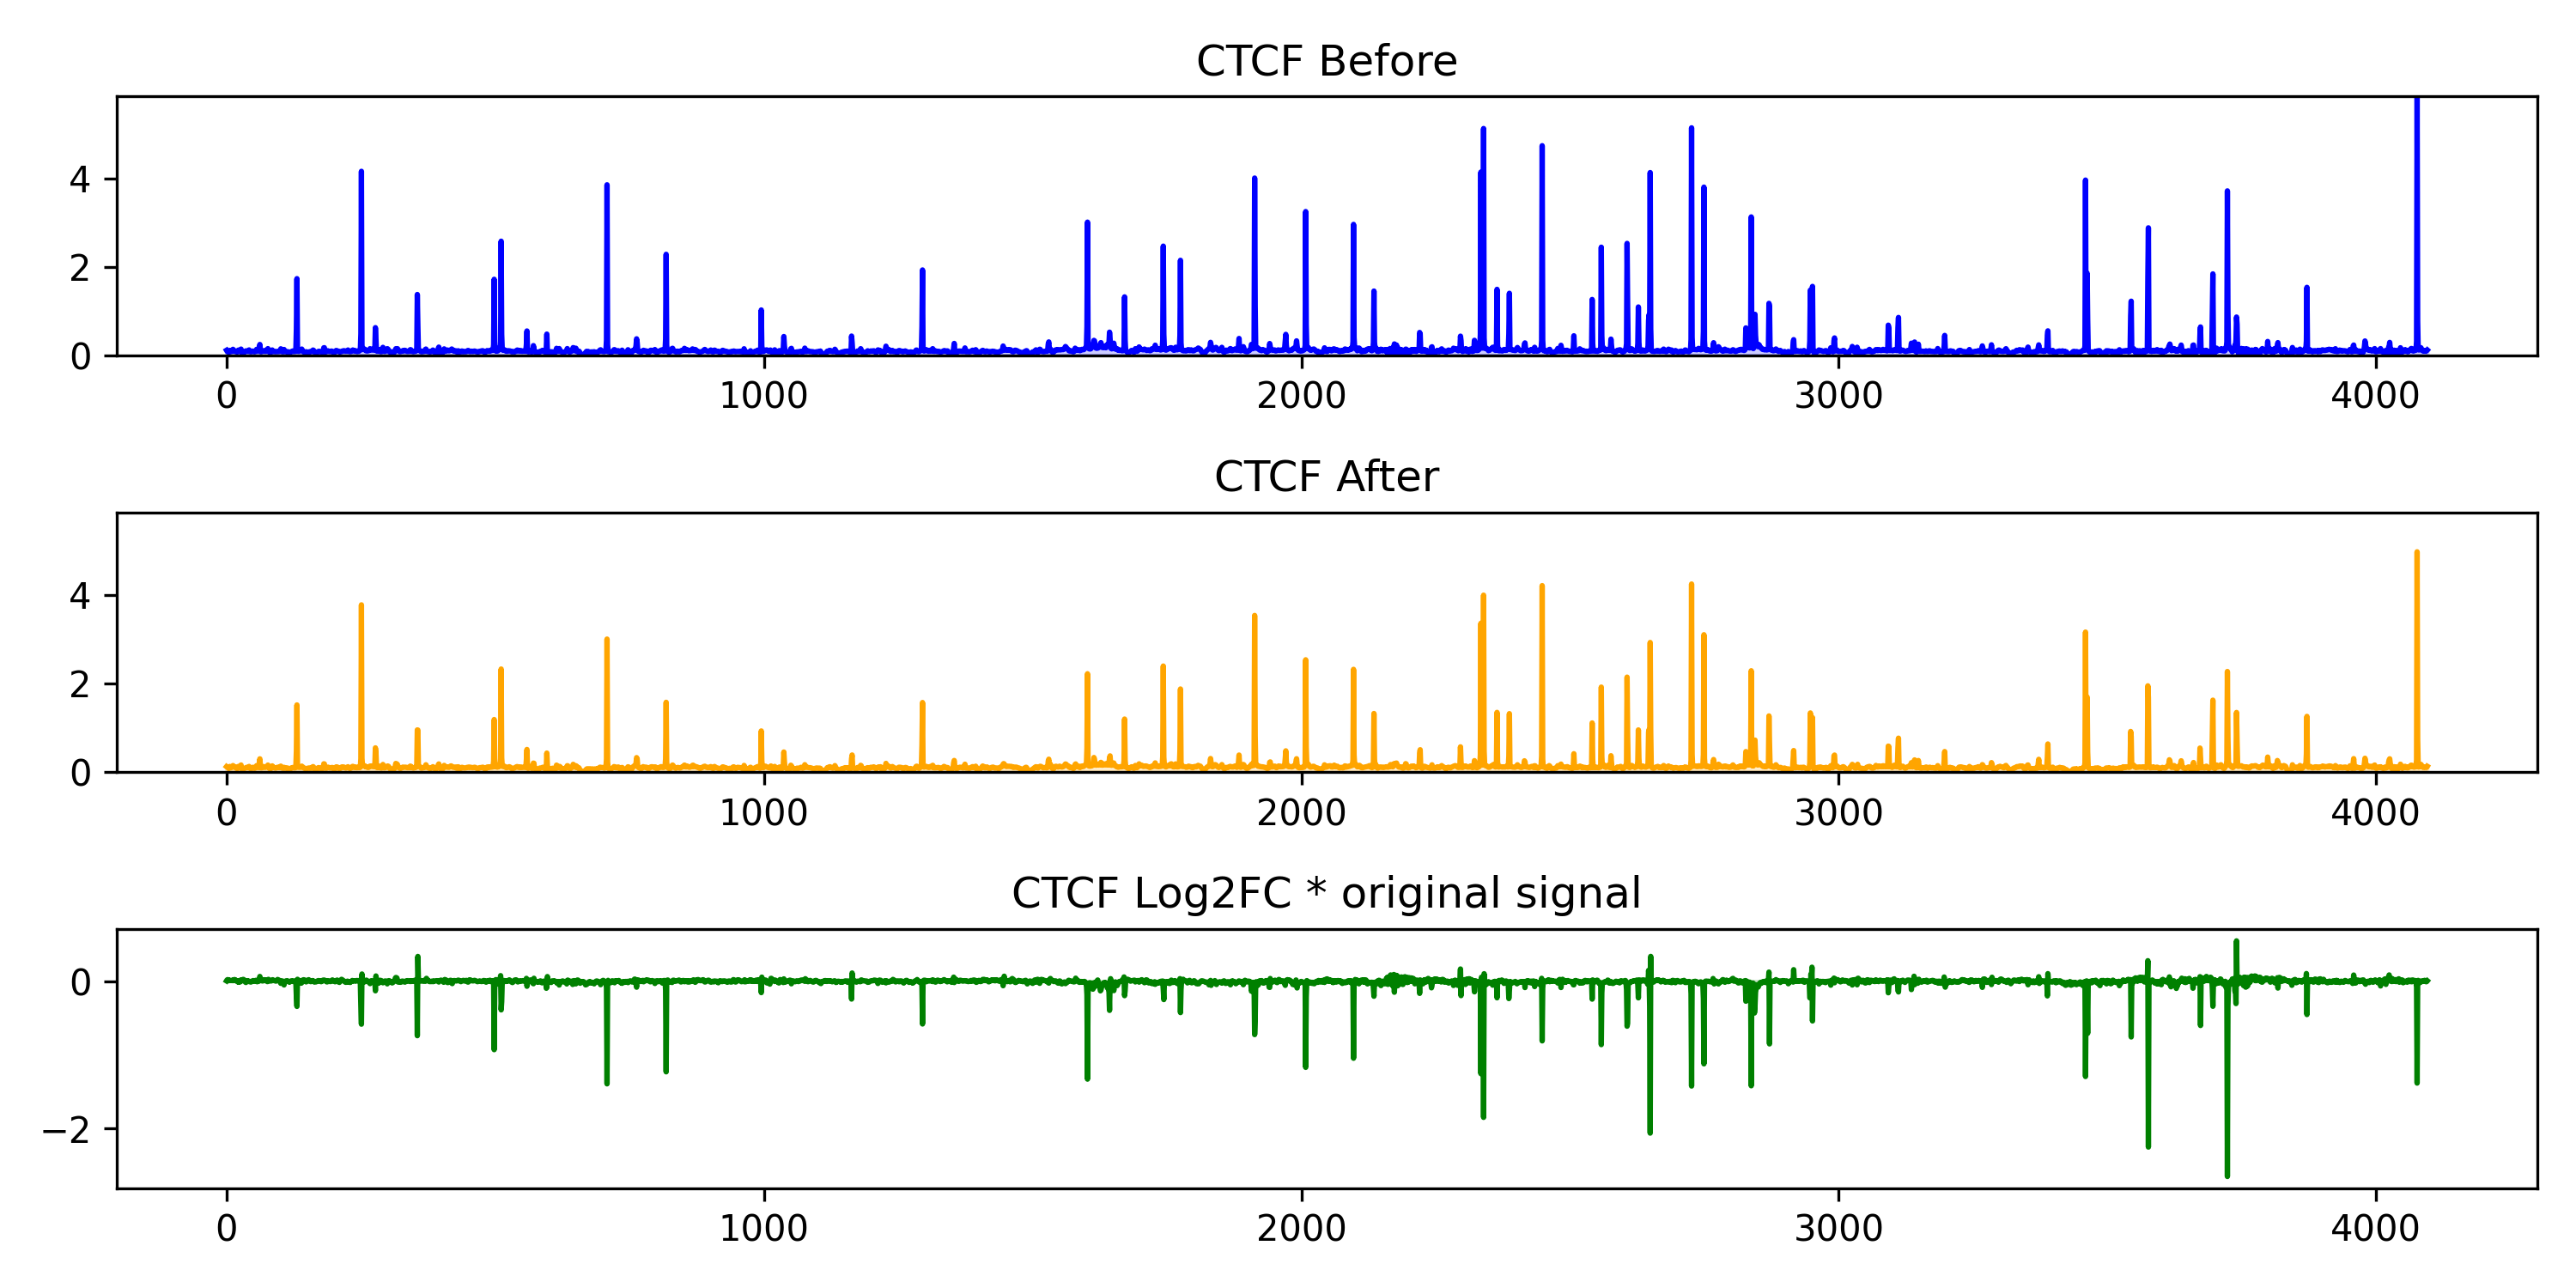

In [8]:
Image(filename=f'outputs/ctcf_ko_only_hESC_WT_5kb_norm_10_{chrom}_{start}_ctcf_log2fc.png', width=600)

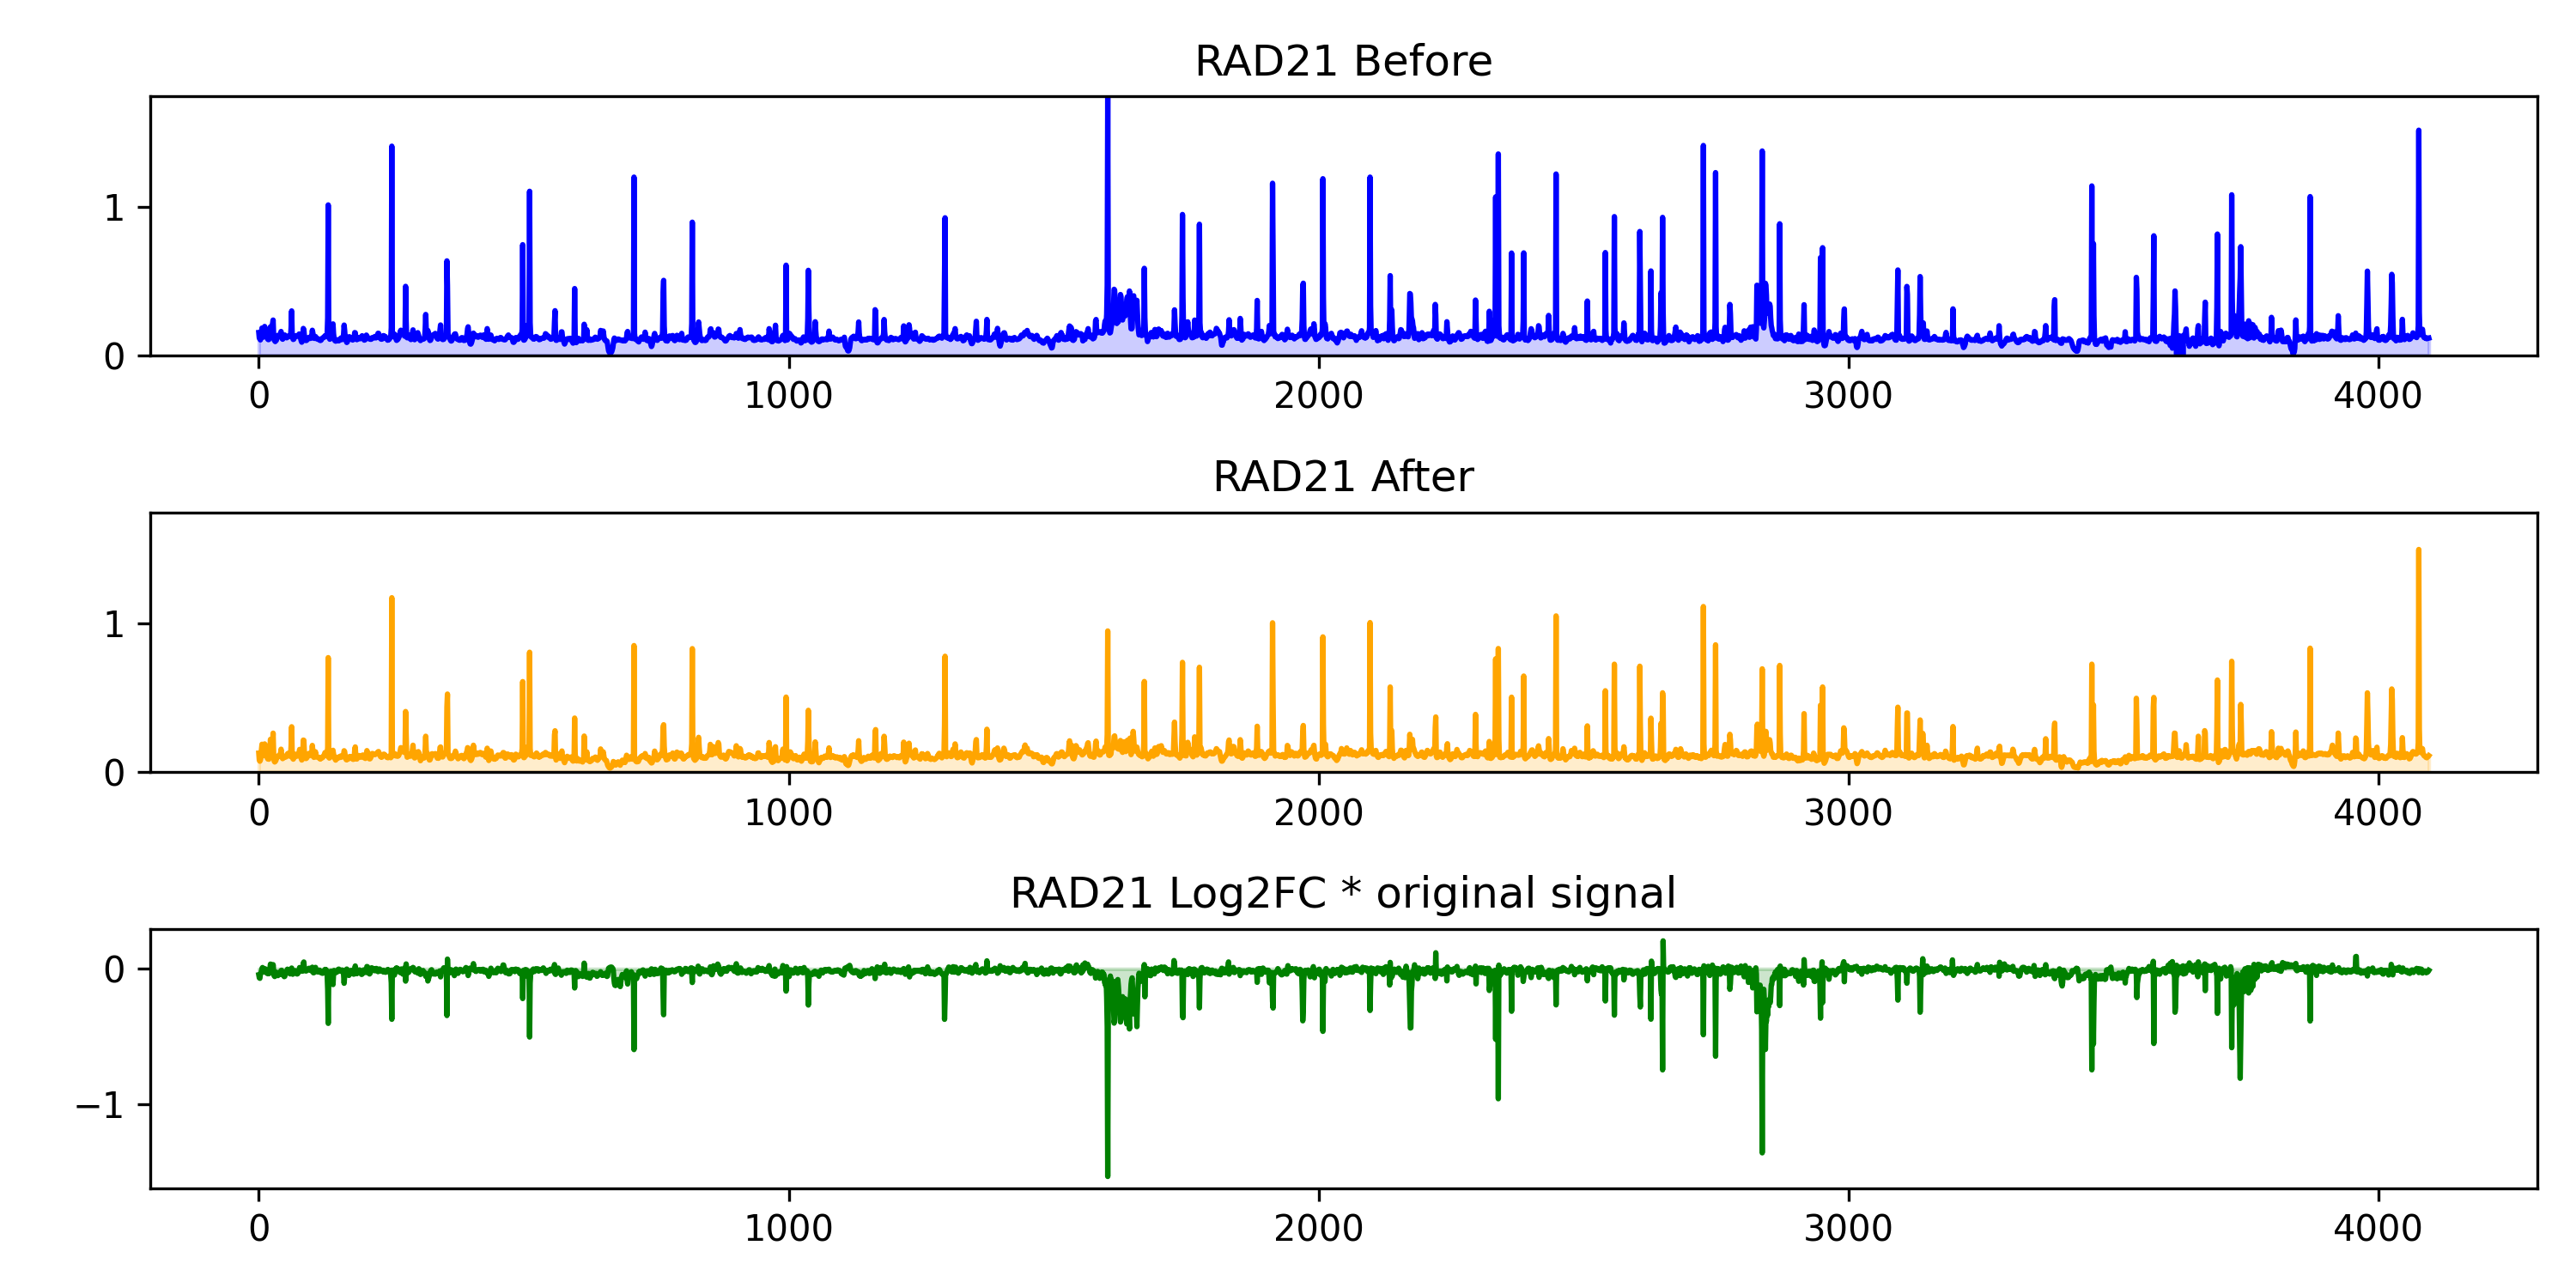

In [9]:
Image(filename=f'outputs/ctcf_ko_only_hESC_WT_5kb_norm_10_{chrom}_{start}_rad21_log2fc.png', width=600)

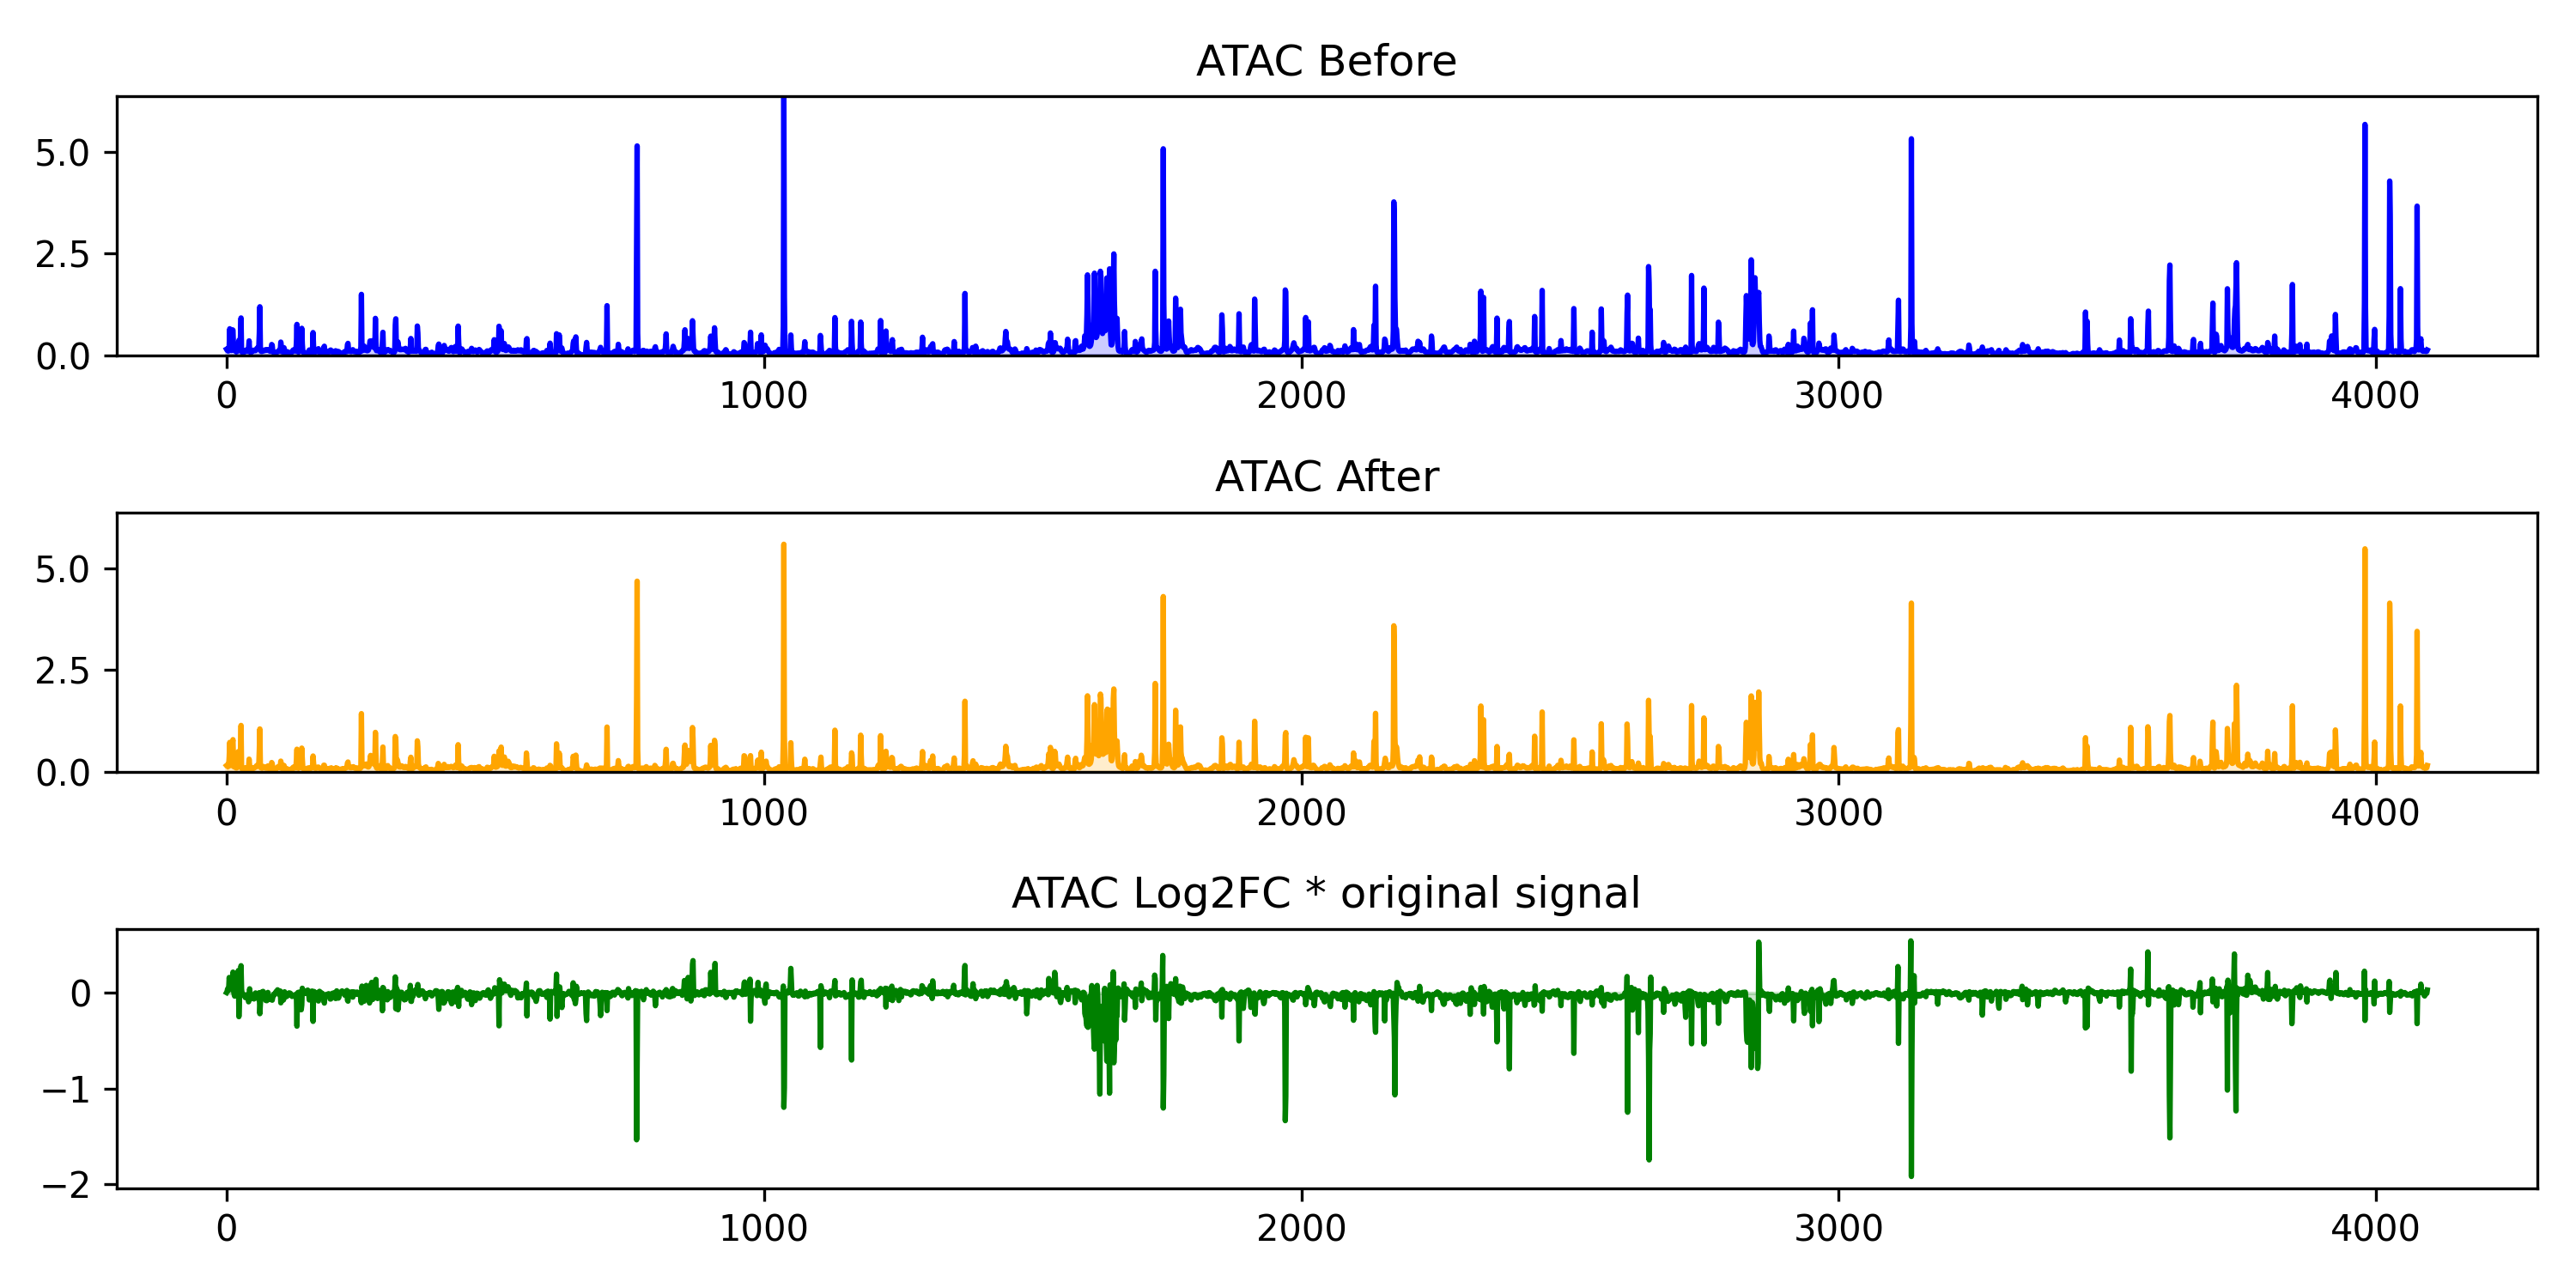

In [10]:
Image(filename=f'outputs/ctcf_ko_only_hESC_WT_5kb_norm_10_{chrom}_{start}_atac_log2fc.png', width=600)

In [11]:
! python ../src/cshark/inference/perturb.py \
    --celltype hESC_WT_5kb_norm_10 \
    --outname ctcf_ko_only \
    --chr $chrom \
    --start $start \
    --model $checkpoint \
    --seq ../cshark_data/data/hg19/dna_sequence \
    --matrix-size 512 \
    --resolution 4096 \
    --region $region \
    --ko-start $ko_start \
    --ko-width $ko_width \
    --ko ctcf \
    --ko-mode knockout \
    --peak-height 0.5 \
    --min-val-pred 0.0 \
    --plot-bigwigs rad21 \
    --plot-pred-bigwigs ctcf atac rad21 \
    --bigwigs ctcf=../cshark_data/data/hg19/hESC_WT_5kb_norm_10/genomic_features/ctcf.bw \
              atac=../cshark_data/data/hg19/hESC_WT_5kb_norm_10/genomic_features/atac.bw \
    --silent

(4096, 5)
(4096, 5)


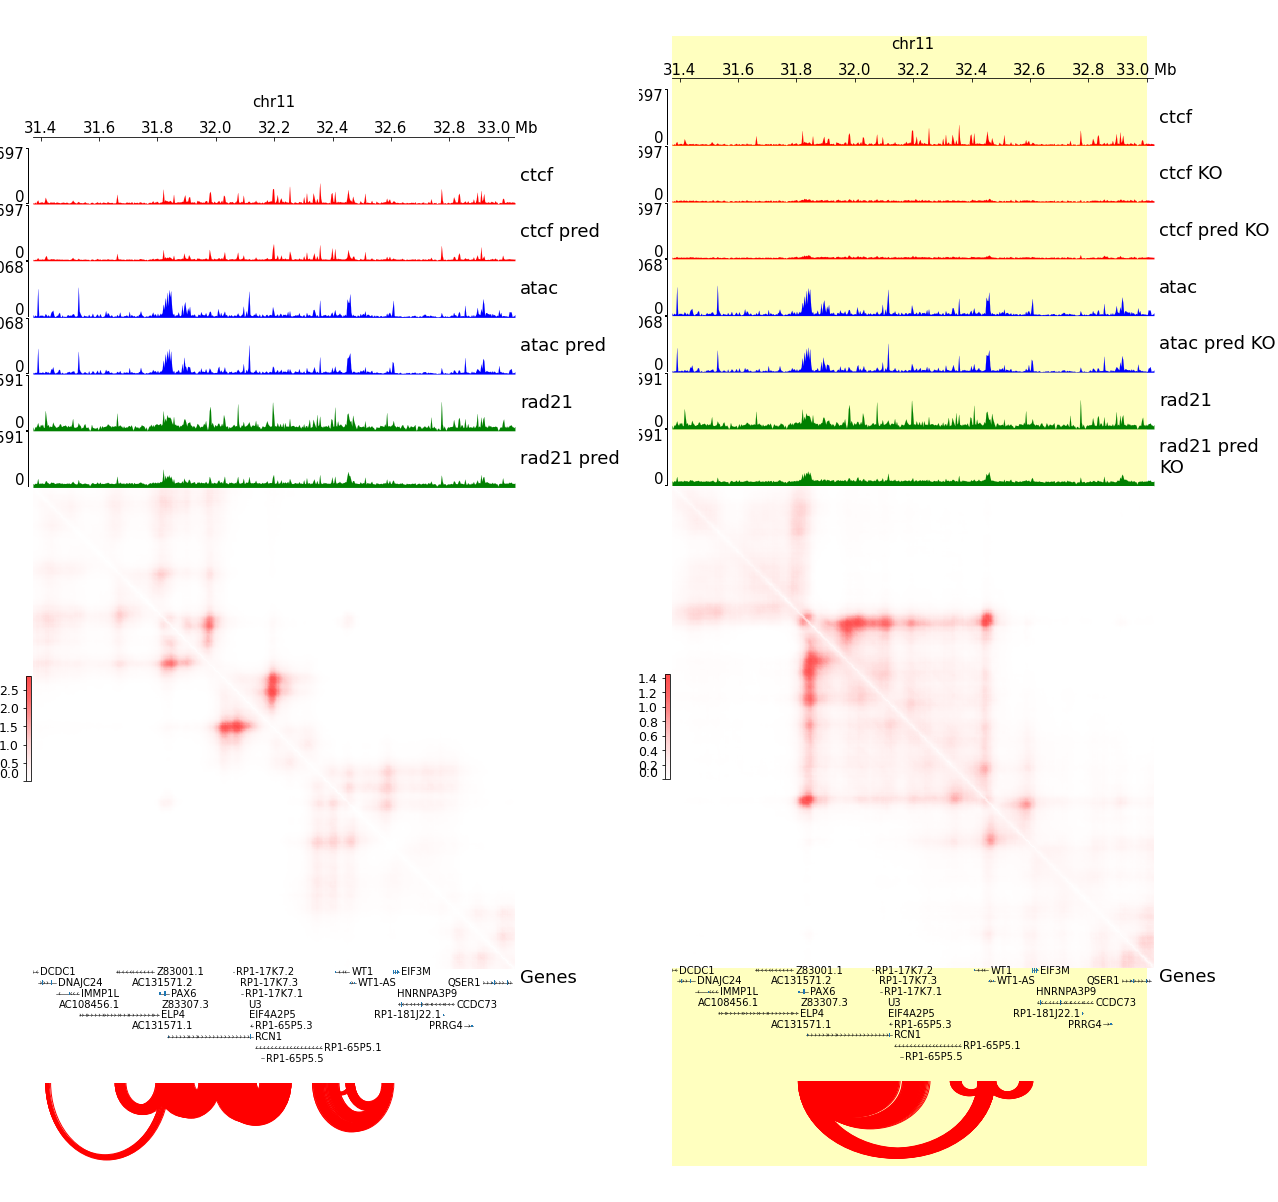

In [12]:
display_images(f'outputs/ctcf_ko_only_hESC_WT_5kb_norm_10_{chrom}_{start}_ctcf_pred_tracks.png', 
               f'outputs/ctcf_ko_only_hESC_WT_5kb_norm_10_{chrom}_{start}_ctcf_ko_tracks.png')

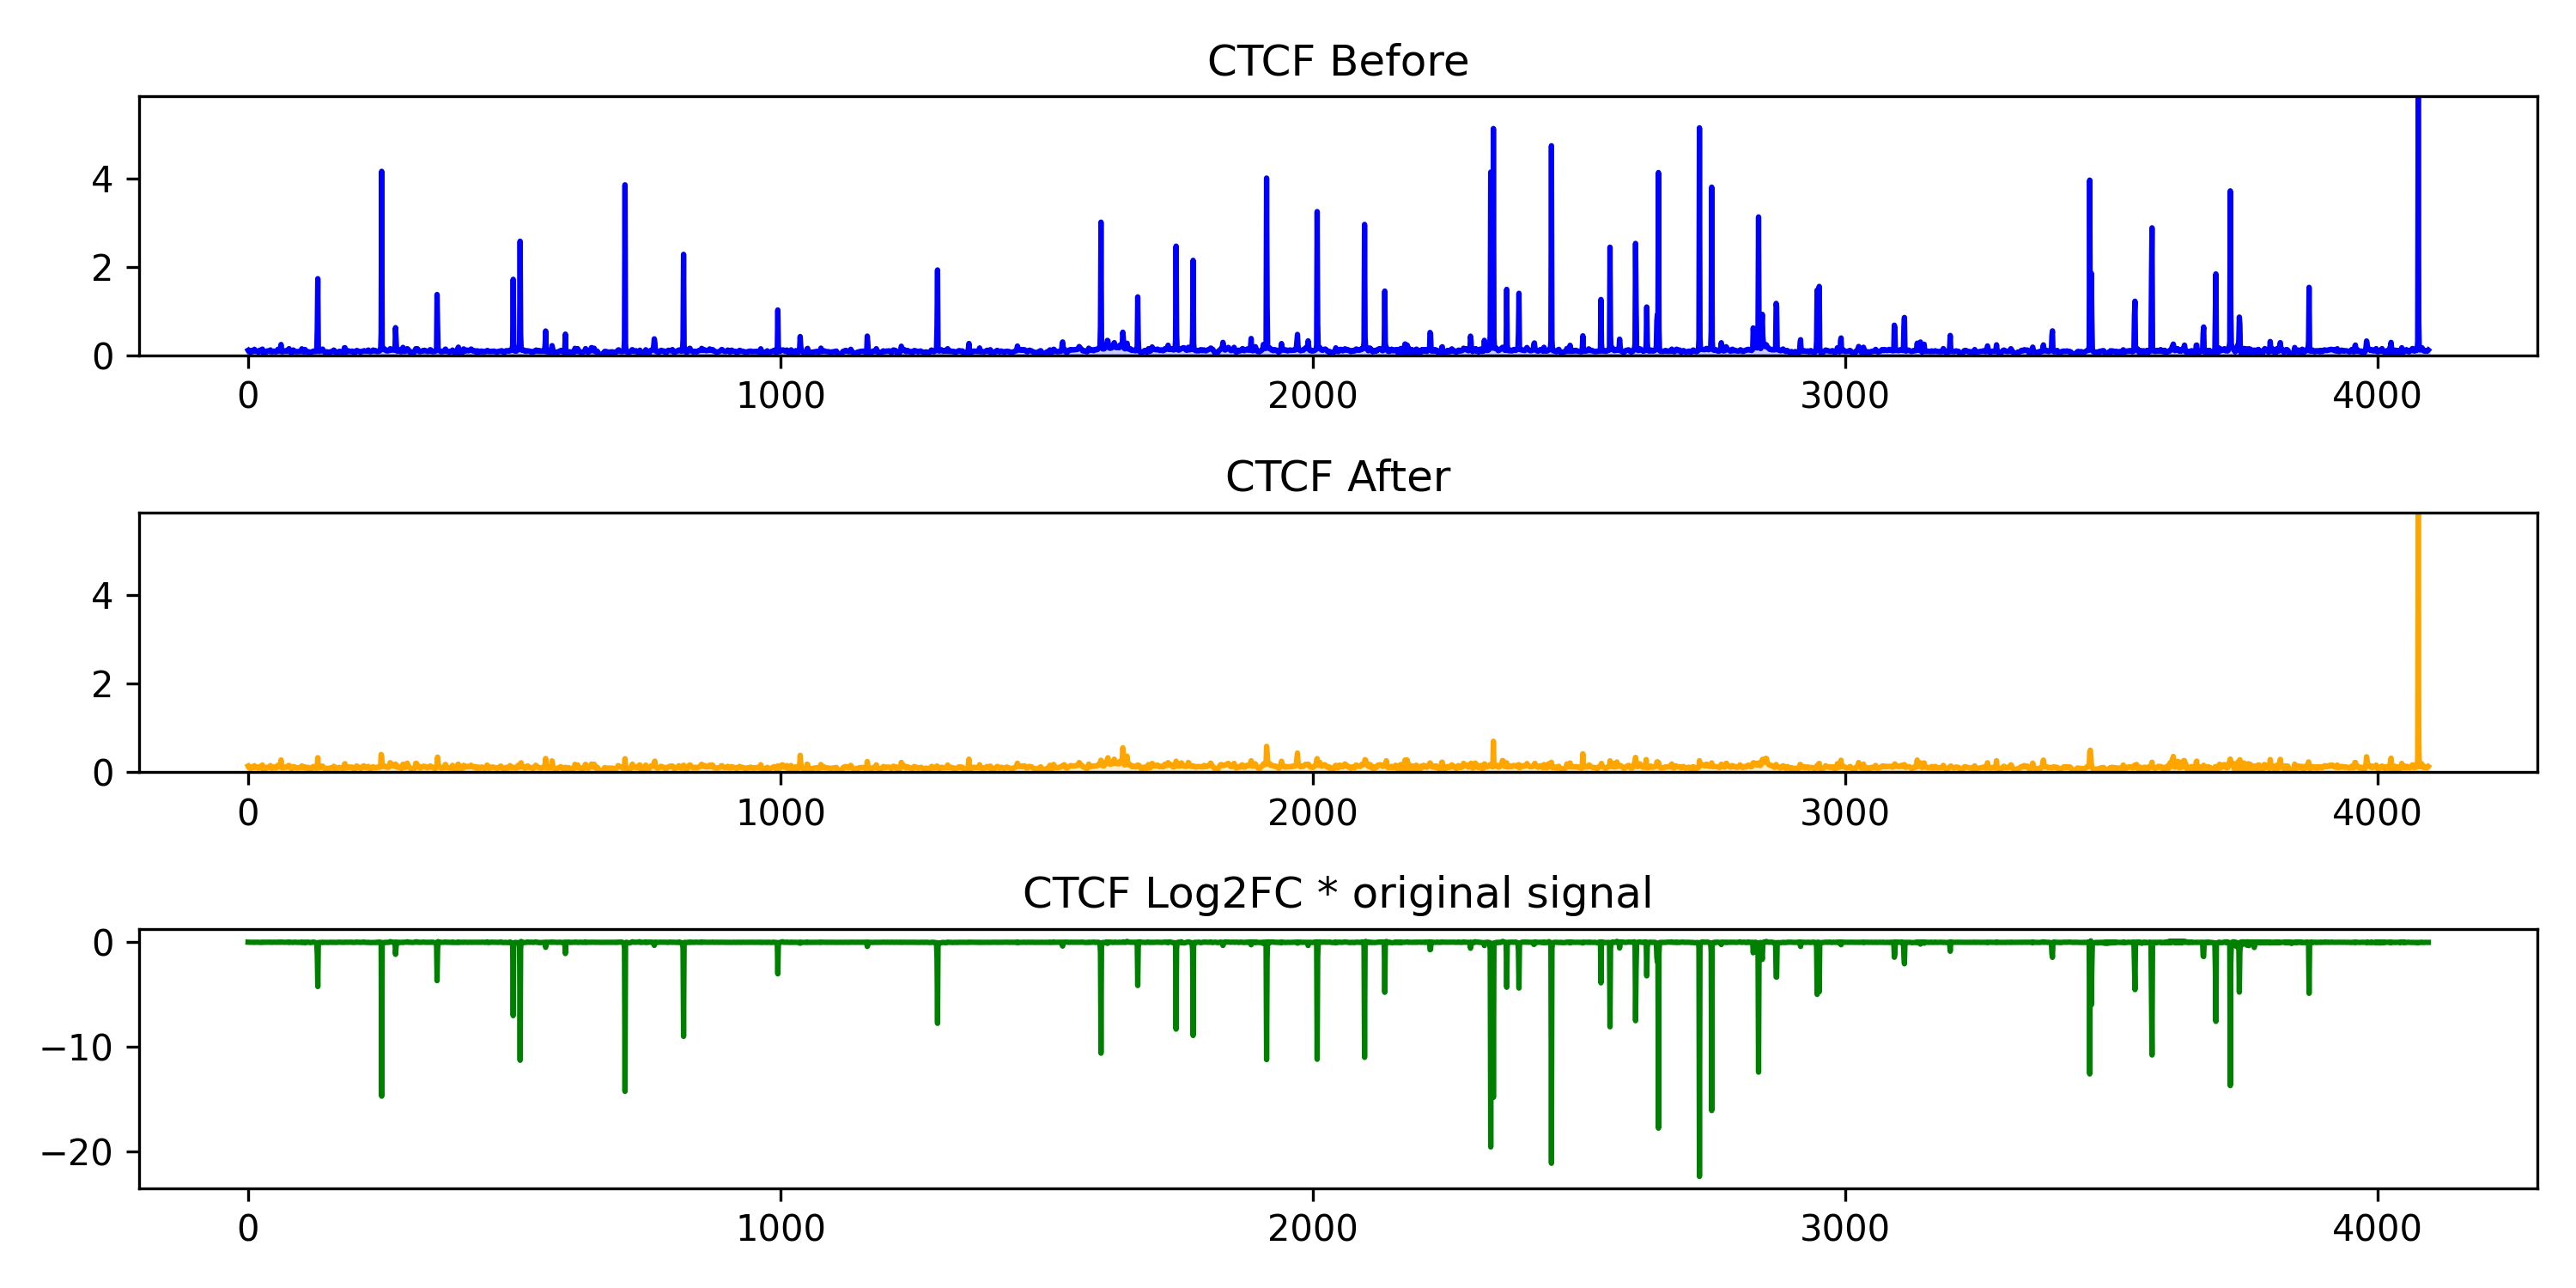

In [13]:
Image(filename=f'outputs/ctcf_ko_only_hESC_WT_5kb_norm_10_{chrom}_{start}_ctcf_log2fc.png', width=600)

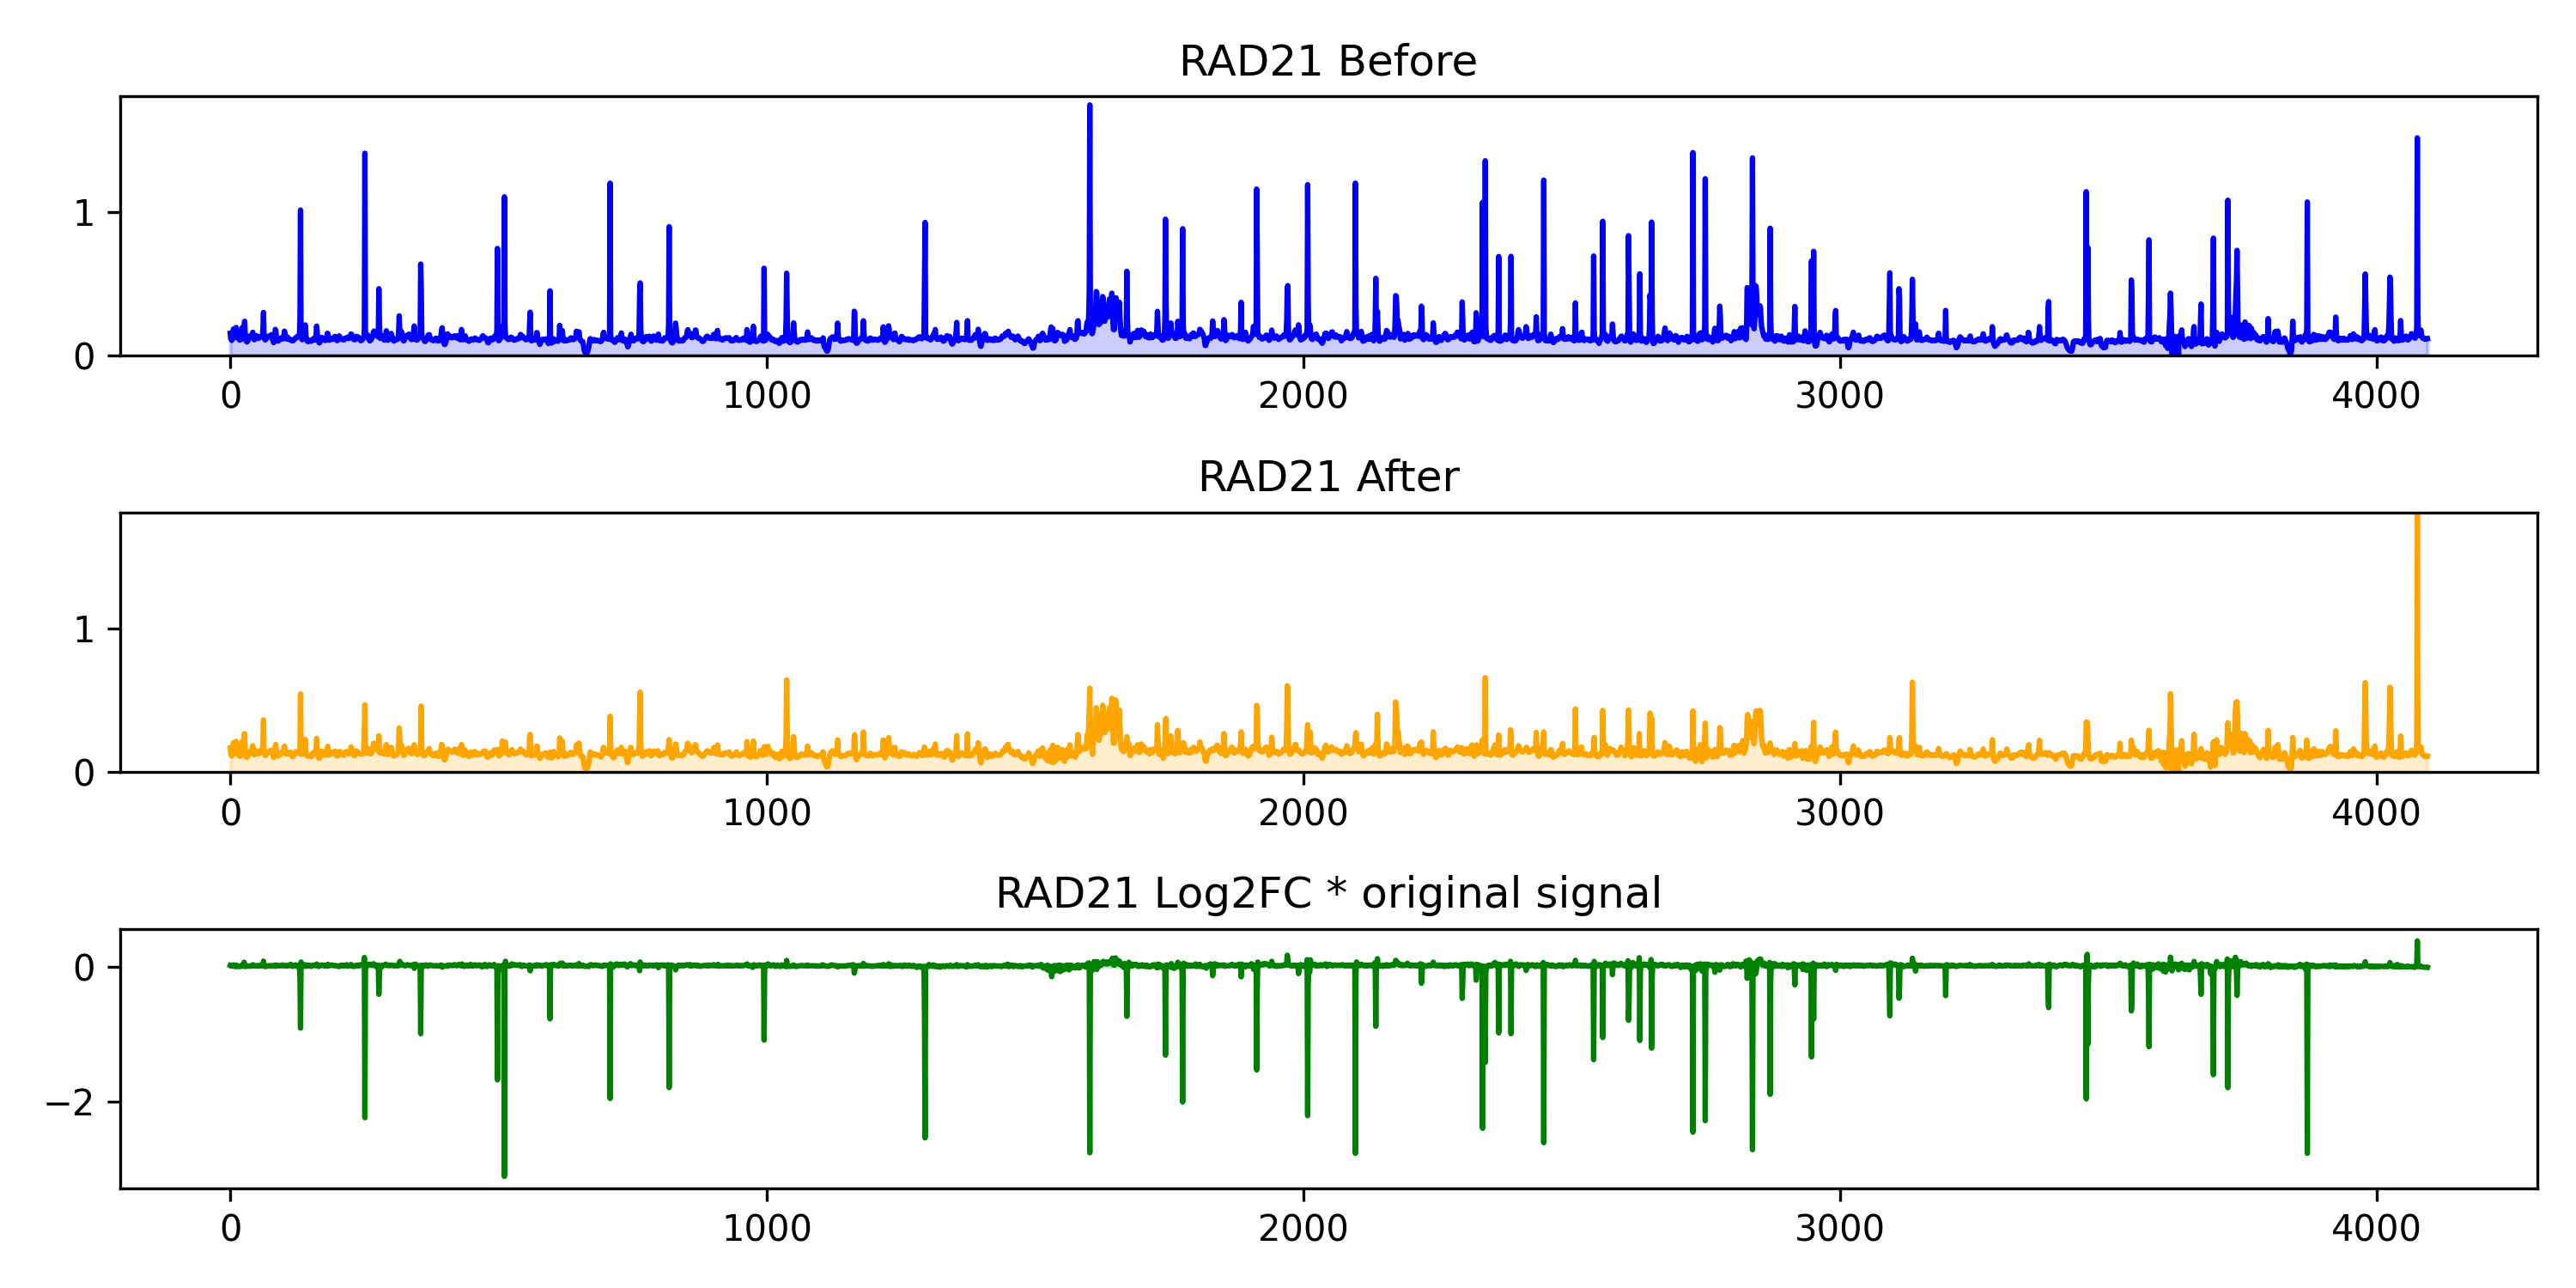

In [14]:
Image(filename=f'outputs/ctcf_ko_only_hESC_WT_5kb_norm_10_{chrom}_{start}_rad21_log2fc.png', width=600)

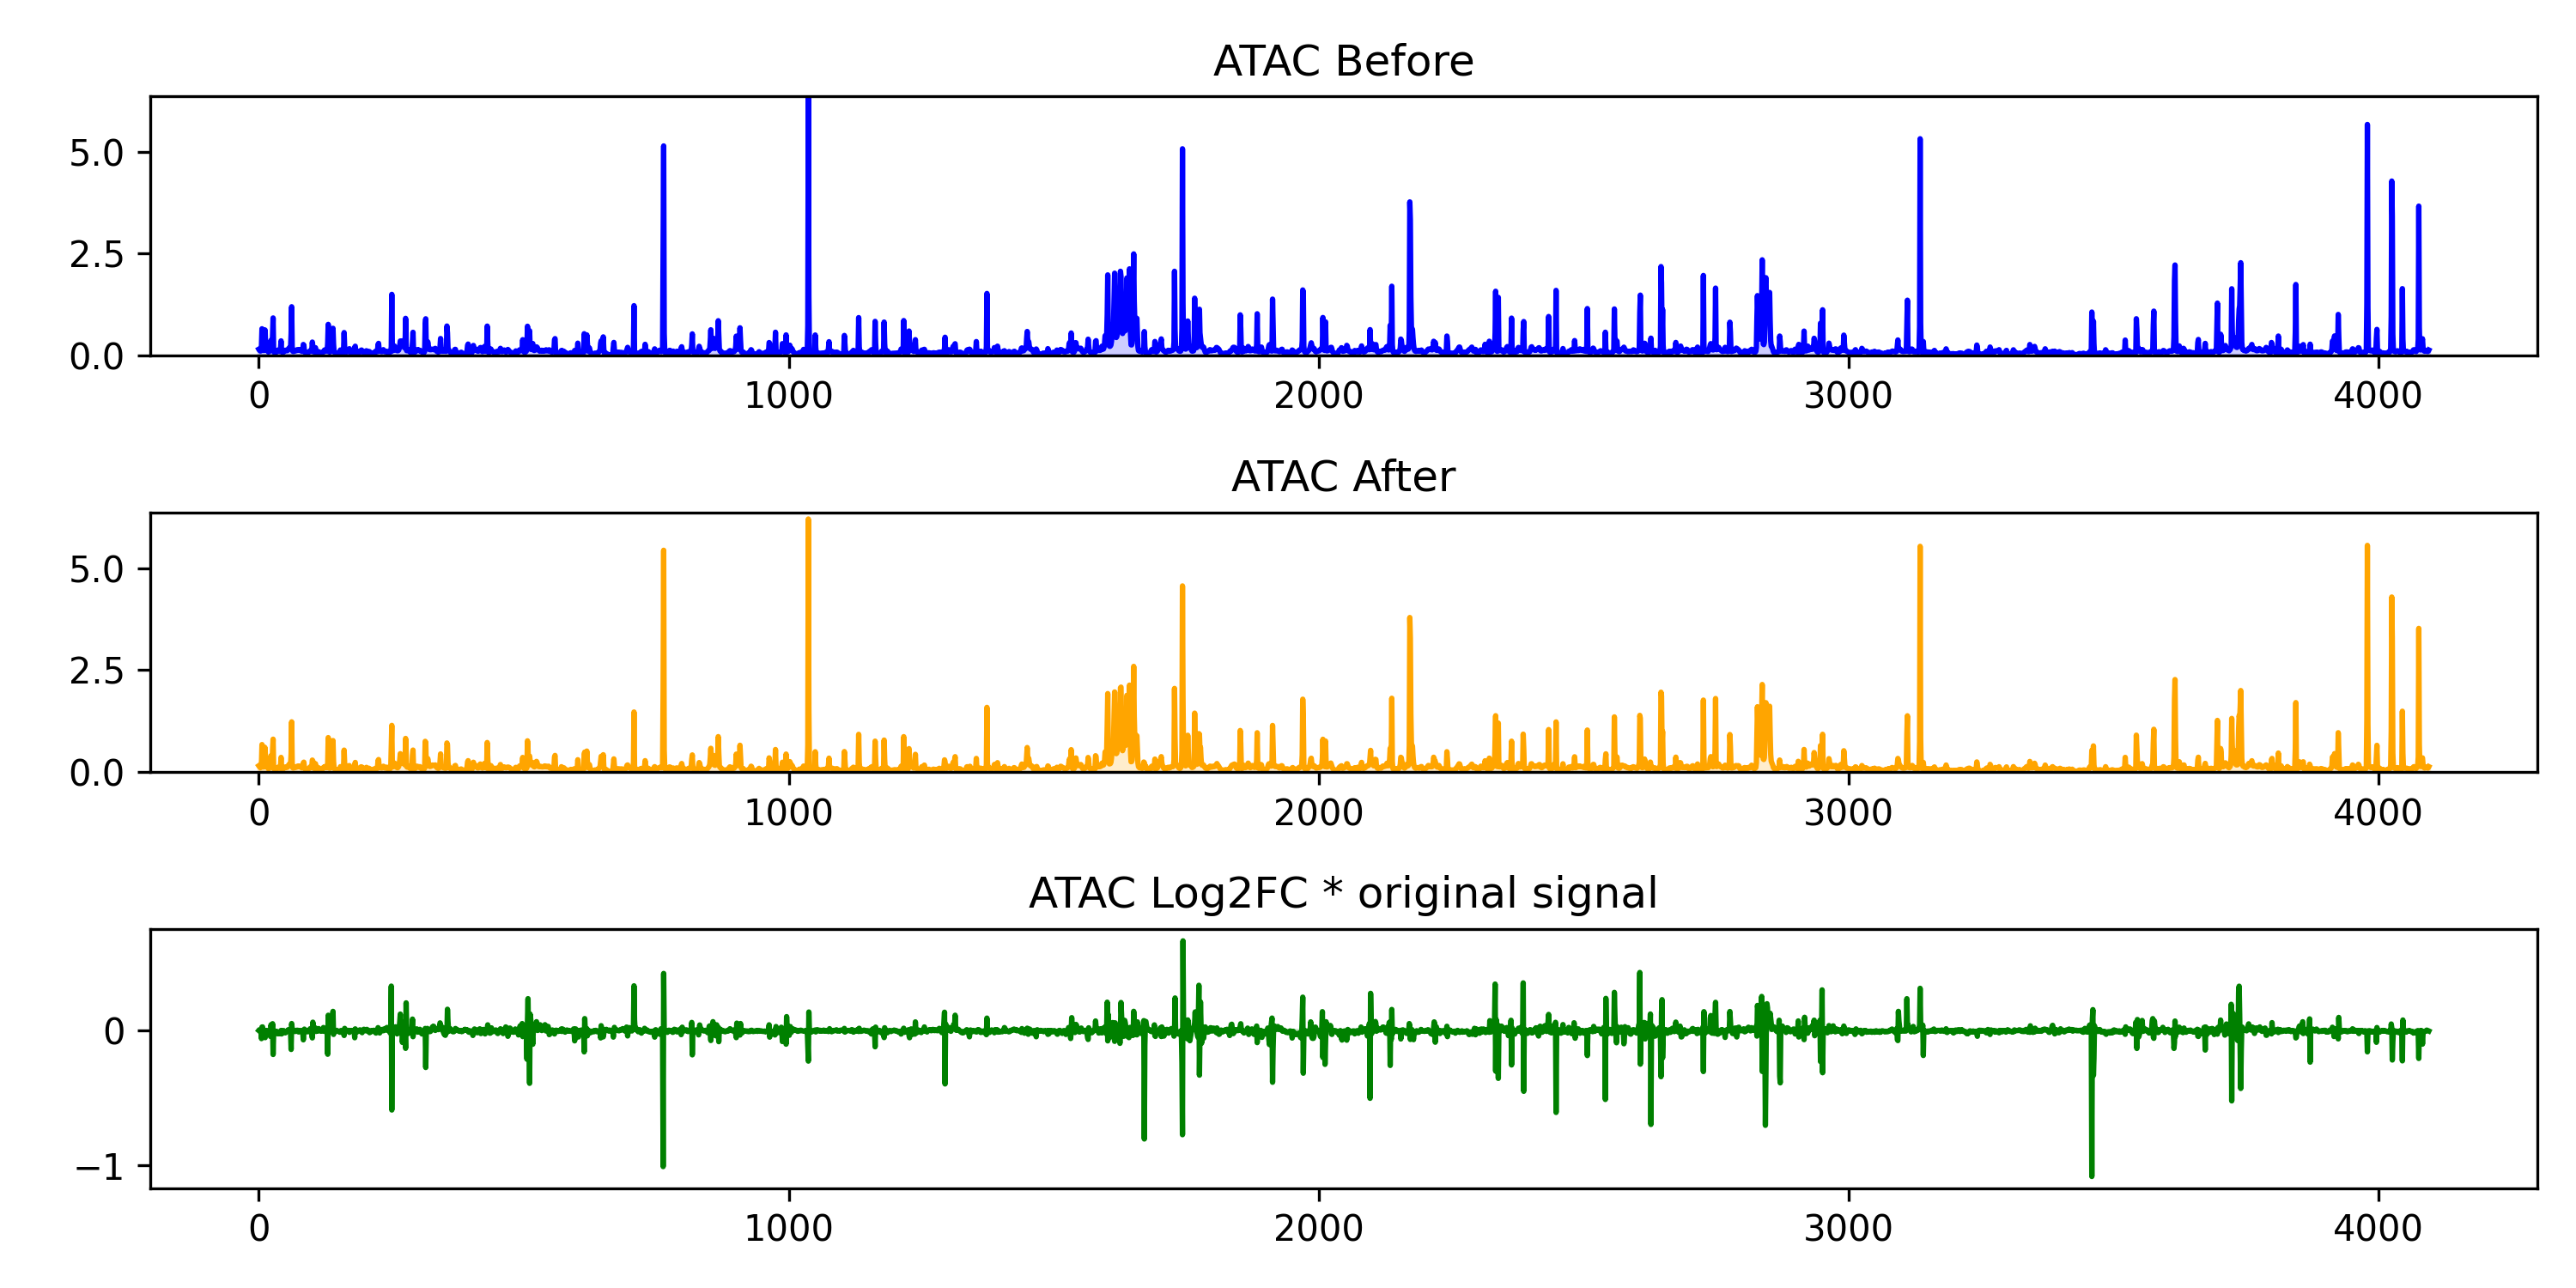

In [15]:
Image(filename=f'outputs/ctcf_ko_only_hESC_WT_5kb_norm_10_{chrom}_{start}_atac_log2fc.png', width=600)

In [16]:
! python ../src/cshark/inference/perturb.py \
    --celltype hESC_WT_5kb_norm_10 \
    --outname ctcf_ko_only \
    --chr $chrom \
    --start $start \
    --model $checkpoint \
    --seq ../cshark_data/data/hg19/dna_sequence \
    --matrix-size 512 \
    --resolution 4096 \
    --region $region \
    --ko-start 31810000 32430000 \
    --ko-width 50000 50000 \
    --ko seq seq \
    --ko-mode shuffle shuffle \
    --peak-height 1.0 \
    --min-val-pred 0.1 \
    --plot-diff \
    --min-val-diff -0.3 \
    --max-val-diff 0.3 \
    --plot-bigwigs rad21 \
    --plot-pred-bigwigs ctcf atac rad21 \
    --bigwigs ctcf=../cshark_data/data/hg19/hESC_WT_5kb_norm_10/genomic_features/ctcf.bw \
              atac=../cshark_data/data/hg19/hESC_WT_5kb_norm_10/genomic_features/atac.bw \
    --silent

(4096, 5)
(4096, 5)


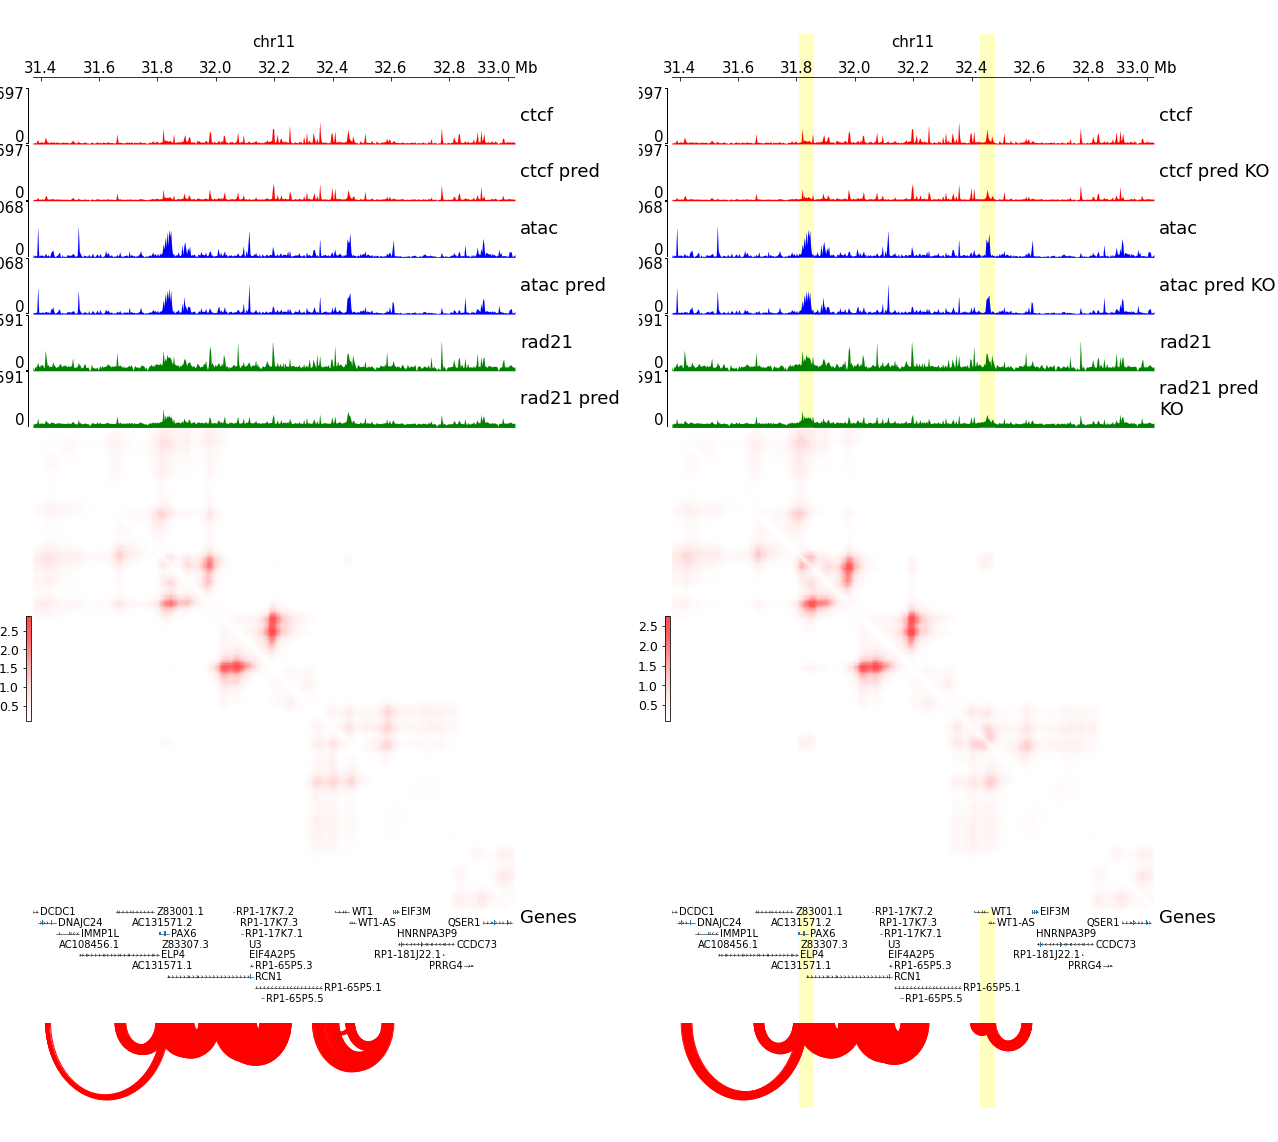

In [17]:
display_images(f'outputs/ctcf_ko_only_hESC_WT_5kb_norm_10_{chrom}_{start}_ctcf_pred_tracks.png', 
               f'outputs/ctcf_ko_only_hESC_WT_5kb_norm_10_{chrom}_{start}_ctcf_ko_tracks.png')

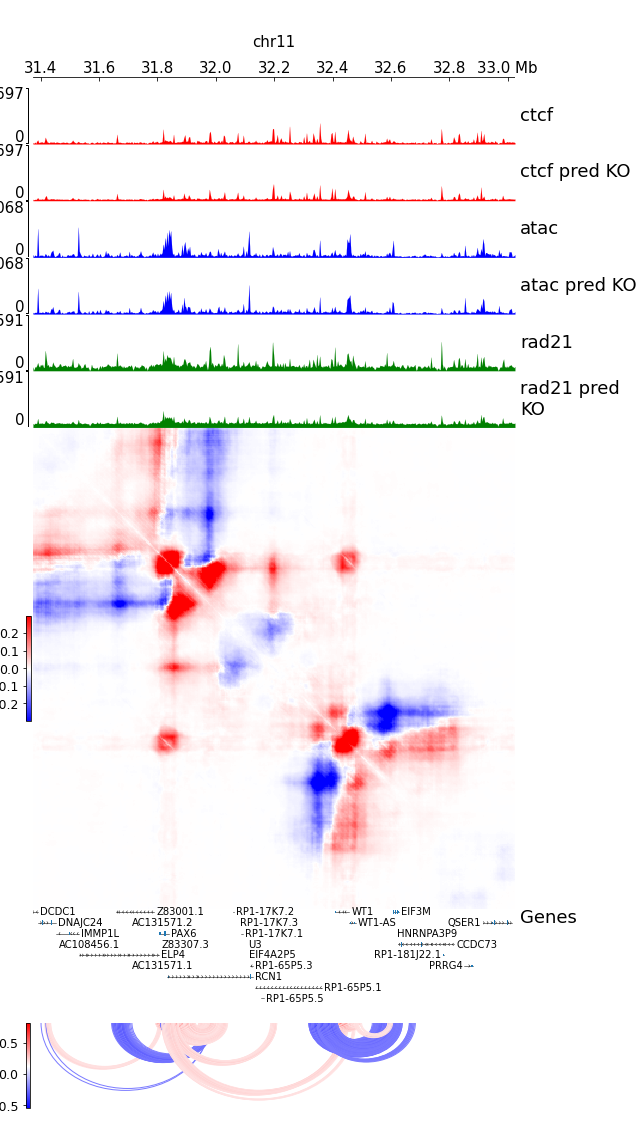

In [18]:
Image(filename=f'outputs/ctcf_ko_only_hESC_WT_5kb_norm_10_{chrom}_{start}_ctcf_ko_tracks_diff.png', width=300)

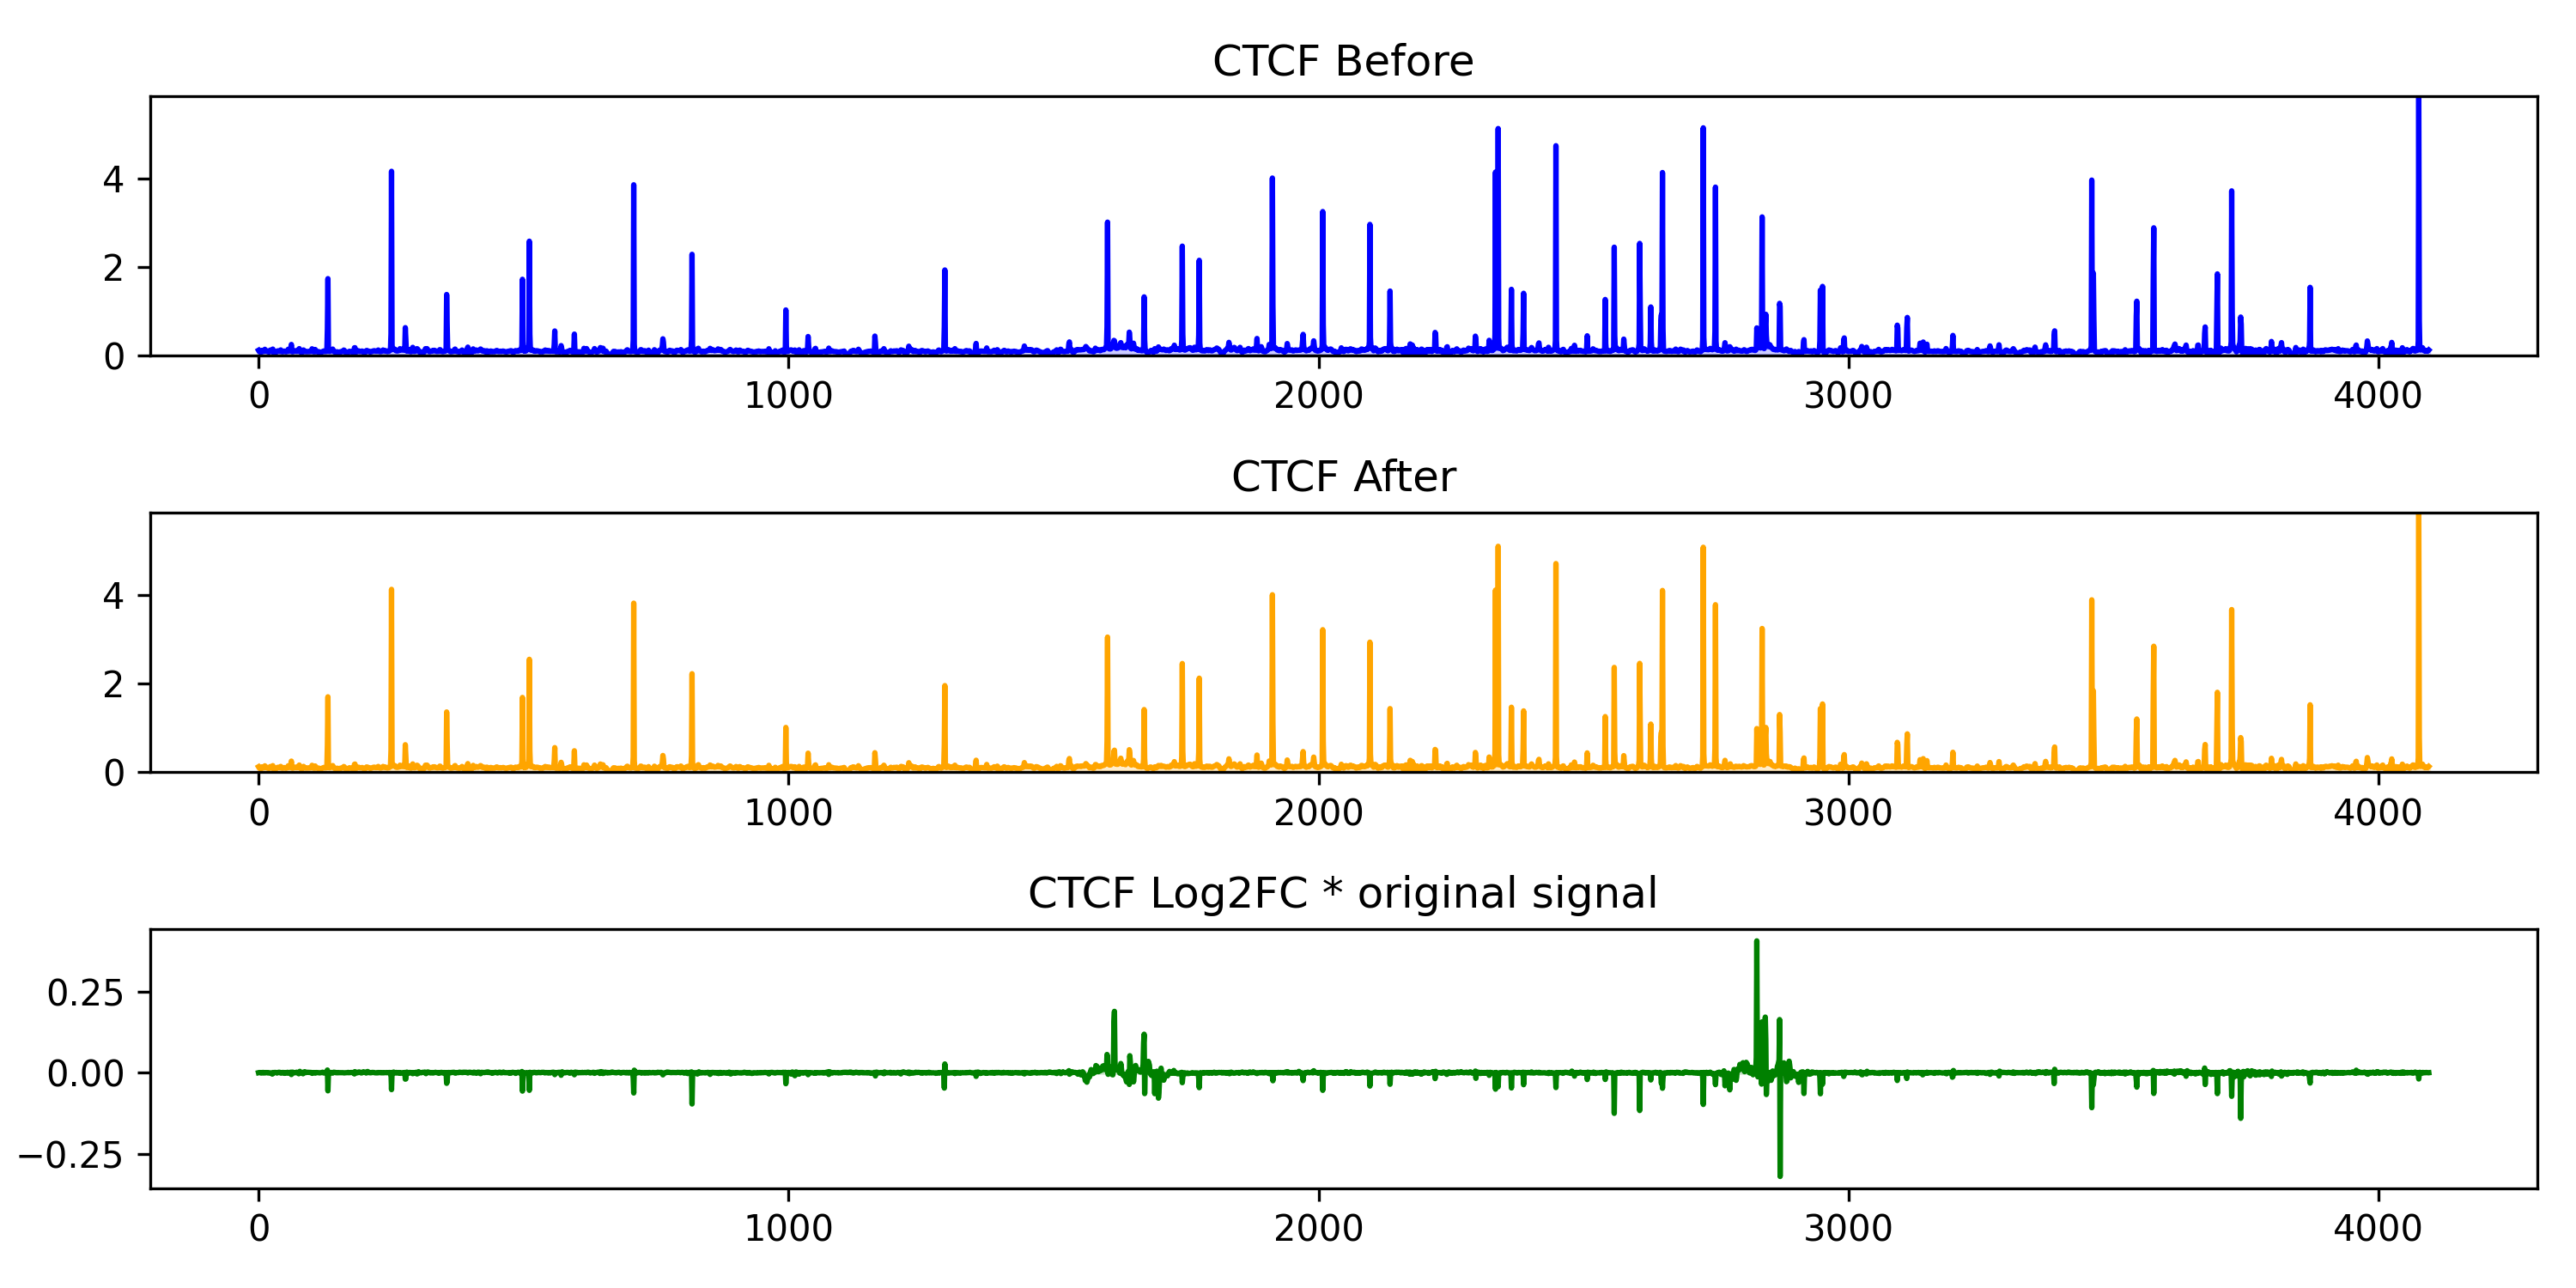

In [19]:
Image(filename=f'outputs/ctcf_ko_only_hESC_WT_5kb_norm_10_{chrom}_{start}_ctcf_log2fc.png', width=600)

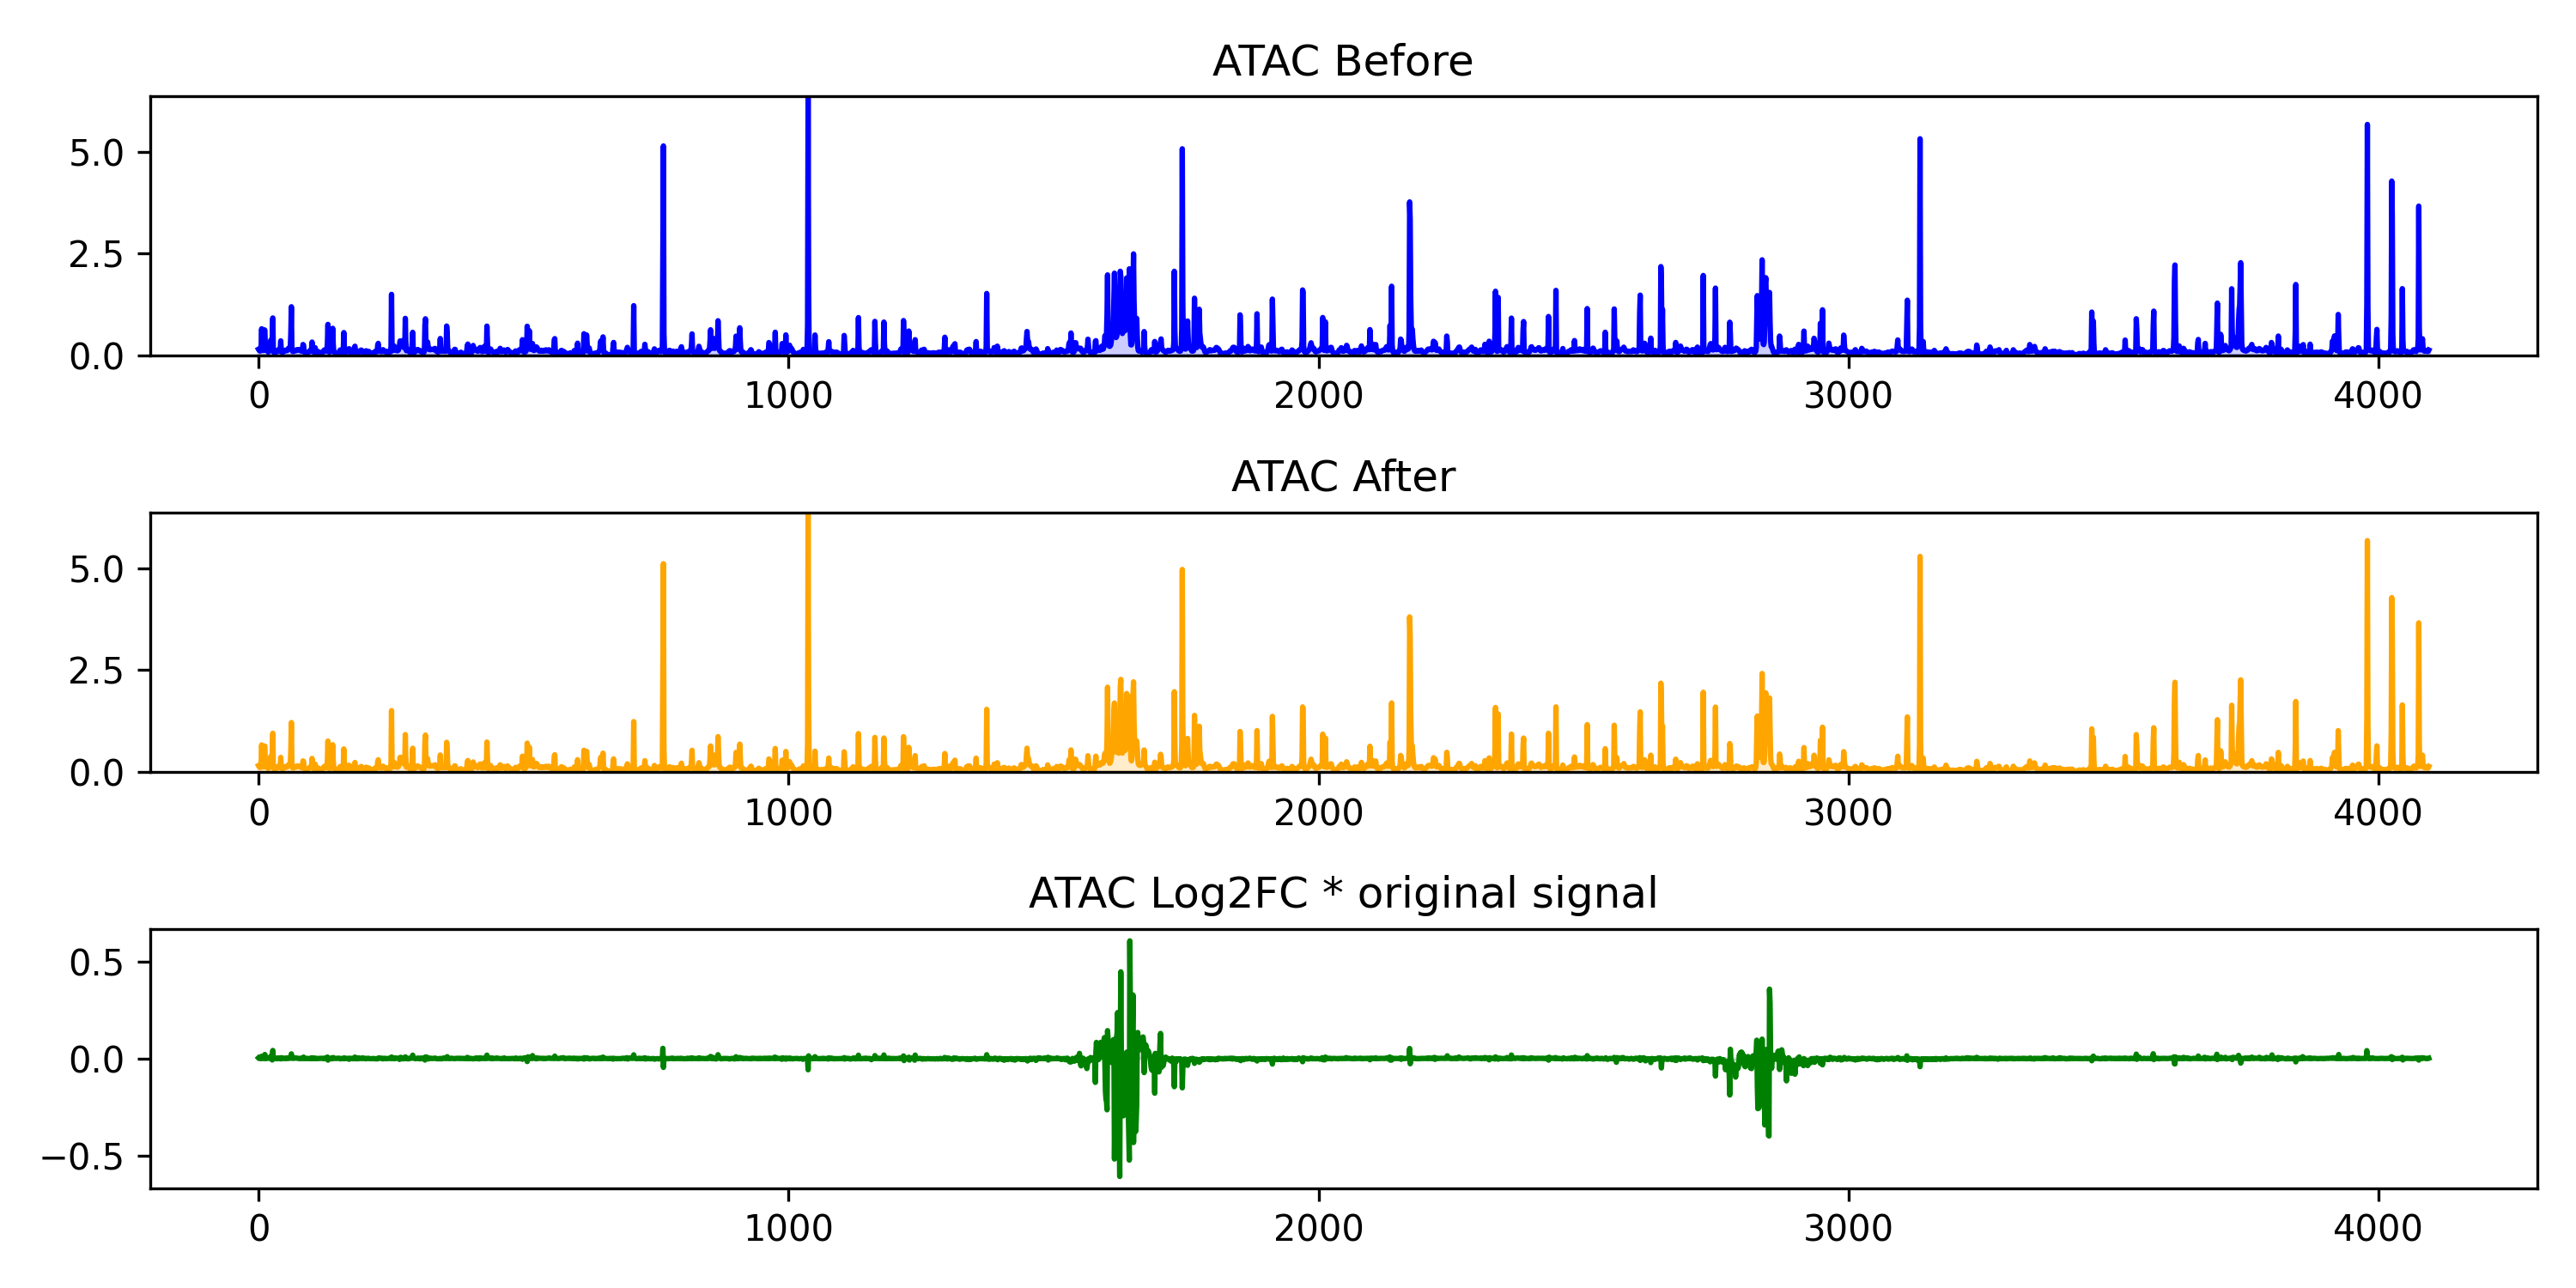

In [20]:
Image(filename=f'outputs/ctcf_ko_only_hESC_WT_5kb_norm_10_{chrom}_{start}_atac_log2fc.png', width=600)

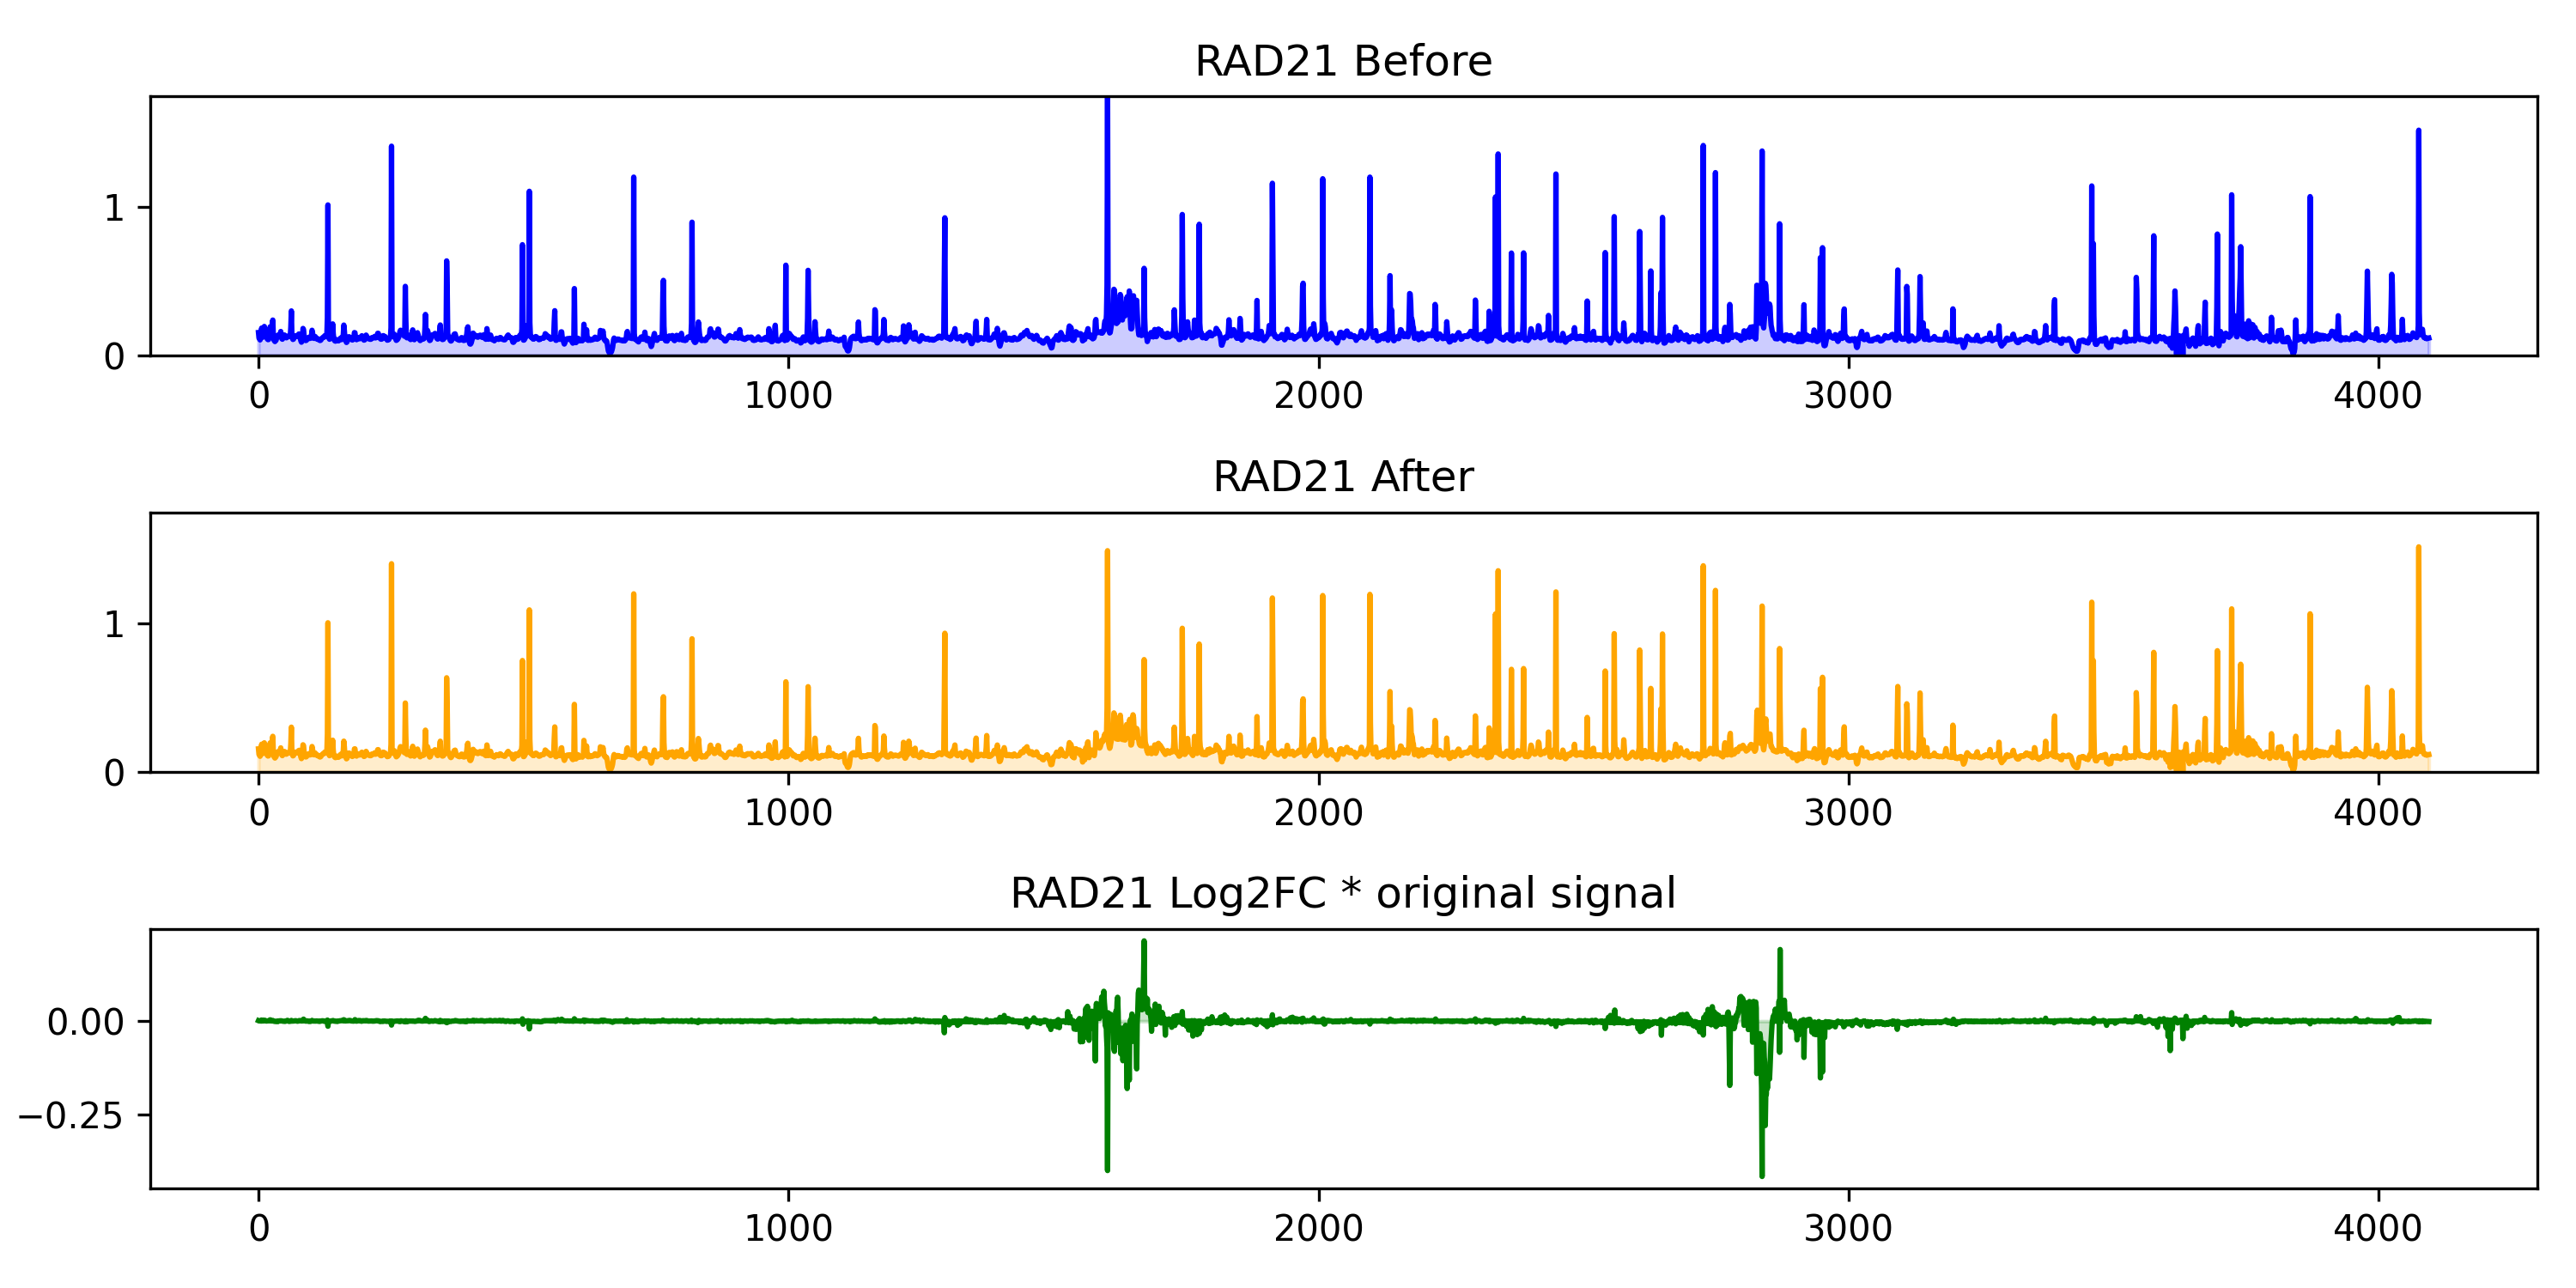

In [21]:
Image(filename=f'outputs/ctcf_ko_only_hESC_WT_5kb_norm_10_{chrom}_{start}_rad21_log2fc.png', width=600)